# Phase 2 — Full-Scale Real-Time Semantic Segmentation
## BDD100K: Engineering Tricks + DDRNet-23-slim + 30 FPS
### v9 — GPU-MAX Edition (T4 15 GB fully utilised)

---

### Project Goal
Build a **highly optimised semantic segmentation model** that distinguishes:
- **Drivable Road** (green)
- **Pedestrians** (red)
- **Vehicles** (blue)
- **Background** (black)

in real time at **≥30 FPS** on a single GPU, maintaining high mIoU on BDD100K (70K images).

---

### Key Design Decisions (v5)

| What | Why |
|---|---|
| **5,000 random train samples/epoch** | Each epoch ~6 min instead of 1h40min; 250 epochs feasible |
| **10,000 random val samples/epoch** | Fast, unbiased validation signal each epoch |
| **Full 70K pool loaded into memory index** | Every epoch draws from the full dataset — model sees all images over time |
| **New random draw every epoch** | Different images each epoch → diversity = better generalisation |
| **Best checkpoint saved on every mIoU improvement** | Never lose your best weights |
| **Overfitting/underfitting detection** | Train vs val loss gap printed and plotted every epoch |

---

### Engineering Tricks Demonstrated (Chapter 7 / PPT-7)

| Section | Engineering Trick | Proof |
|---|---|---|
| Section 9 | **Trick #1 — Data Sharding** | `ShardedBDD100KDataset` + `worker_init_fn` + `get_worker_info()` |
| Section 12 | **Trick #2 — Mixed-Precision (FP16)** | `GradScaler(enabled=True)` + `with autocast():` |
| Section 15 | **30+ FPS Proof** | 100-frame timed test, CUDA synchronised, printed `FPS: XX.X ✅` |

---

**Run on Google Colab with T4 GPU.**
**Runtime > Change runtime type > T4 GPU**
If session disconnects, re-run from top — the notebook auto-resumes from the latest checkpoint.

## Section 1 — Install & Imports

In [1]:
# Install all dependencies
!pip install -q albumentations segmentation-models-pytorch torchinfo yacs
!pip install -q onnxruntime-gpu 2>/dev/null || pip install -q onnxruntime
!pip install -q opencv-python-headless 2>/dev/null
!pip install -q timm   # needed for ImageNet pretrained backbone weights

# Clone DDRNet repo (skip if already cloned)
import os
if not os.path.exists('/content/DDRNet.pytorch'):
    !git clone https://github.com/chenjun2hao/DDRNet.pytorch.git /content/DDRNet.pytorch
else:
    print('DDRNet.pytorch already cloned — skipping.')

print('All dependencies ready.')


# ── GPU Memory Monitor helper (run any time to check utilisation) ─────────────
def gpu_mem():
    if torch.cuda.is_available():
        alloc  = torch.cuda.memory_allocated()  / 1e9
        reserv = torch.cuda.memory_reserved()   / 1e9
        total  = torch.cuda.get_device_properties(0).total_memory / 1e9
        print(f'GPU memory  allocated={alloc:.2f}GB  reserved={reserv:.2f}GB  total={total:.1f}GB  '
              f'utilisation={alloc/total*100:.1f}%')
    else:
        print('No GPU')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.8/252.8 MB 4.6 MB/s eta 0:00:00
Cloning into '/content/DDRNet.pytorch'...
remote: Enumerating objects: 1039, done.
remote: Counting objects: 100% (193/193), done.
remote: Compressing objects: 100% (45/45), done.
remote: Total 1039 (delta 168), reused 148 (delta 148), pack-reused 846 (from 1)
Receiving objects: 100% (1039/1039), 1.32 MiB | 4.49 MiB/s, done.
Resolving deltas: 100% (660/660), done.
All dependencies ready.


In [2]:
import os, glob, json, random, warnings, time, shutil, sys, unittest.mock as mock
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, SubsetRandomSampler
from torch.cuda.amp import GradScaler, autocast

import torchvision.transforms as T
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import confusion_matrix
from tqdm.notebook import tqdm
from torchinfo import summary

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU   : {torch.cuda.get_device_name(0)}')
    print(f'VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('WARNING: No GPU — go to Runtime > Change runtime type > T4 GPU')
# ── GPU Warmup — runs a dummy forward pass to warm up CUDA kernels ───────────
# Without this, the first real training batch is slow and skews timing.
if device.type == 'cuda':
    _dummy = torch.zeros(1, 3, 512, 1024, device=device)
    for _ in range(3):
        _dummy = _dummy + 1
    del _dummy
    torch.cuda.empty_cache()
    print('GPU warmup complete.')


Device: cuda
GPU   : Tesla T4
VRAM  : 15.6 GB
GPU warmup complete.


## Section 2 — Configuration
All constants in one place. These are Phase 2 full-scale settings.

In [3]:
# ── Directories ──────────────────────────────────────────────────────────────
PROJECT_ROOT   = '/content/bdd100k_phase2'
DATA_ROOT      = os.path.join(PROJECT_ROOT, 'data')
RESULTS_DIR    = os.path.join(PROJECT_ROOT, 'results')
CHECKPOINT_DIR = os.path.join(PROJECT_ROOT, 'checkpoints')
SEG_MASK_DIR   = os.path.join(DATA_ROOT, 'labels', 'sem_seg', 'masks')

for d in [PROJECT_ROOT, DATA_ROOT, RESULTS_DIR, CHECKPOINT_DIR, SEG_MASK_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Image Config ──────────────────────────────────────────────────────────────
IMG_HEIGHT        = 512
IMG_WIDTH         = 1024

# ── Sampling Config ───────────────────────────────────────────────────────────
# Each epoch randomly draws this many samples from the full pool.
# Raise EPOCHS at any time — training auto-resumes from latest_checkpoint.pth.
TRAIN_SAMPLES_PER_EPOCH = 5000   # ~6 min/epoch on T4
VAL_SAMPLES_PER_EPOCH   = 2000
MASK_SCAN_SAMPLES       = 5000

# ── Class-Aware Oversampling Config ───────────────────────────────────────────
# Images containing rare classes (Pedestrian, Vehicle) are sampled MORE often.
# RARE_CLASS_IDS   : pixel class IDs to boost (from your 4-class remapping)
# OVERSAMPLE_RATIO : rare-class images are this many times more likely to be picked
# OVERSAMPLE_SCAN  : how many train masks to pre-scan to build the sampling weights
#                    (higher = more accurate weights, but slower startup)
USE_CLASS_AWARE_SAMPLING = True
RARE_CLASS_IDS           = [2, 3]   # 2=Pedestrian, 3=Vehicle
OVERSAMPLE_RATIO         = 3.0      # rare-class images 3x more likely to be sampled
OVERSAMPLE_SCAN          = 10000    # scan this many masks to build weights

# ── Training Config ───────────────────────────────────────────────────────────
NUM_CLASSES     = 4
BATCH_SIZE      = 16  # GPU-MAX: was 4, T4 15GB fits 16 with AMP
EPOCHS          = 110 # raise this freely — resumes from checkpoint automatically
LEARNING_RATE   = 0.01
WEIGHT_DECAY    = 5e-4
IGNORE_INDEX    = 255
SEED            = 42
AUX_LOSS_WEIGHT = 0.4

# ── Sharding / DataLoader Config ──────────────────────────────────────────────
NUM_WORKERS = 4   # 4 workers is optimal for Colab T4
NUM_SHARDS  = 4

# ── Loss Config ───────────────────────────────────────────────────────────────
USE_DICE_LOSS = True
DICE_WEIGHT   = 0.5

# ── Early Stopping ────────────────────────────────────────────────────────────
EARLY_STOP_PATIENCE = 20

# ── LR Warmup ─────────────────────────────────────────────────────────────────
WARMUP_EPOCHS = 3

# ── Gradient Clipping ────────────────────────────────────────────────────────
GRAD_CLIP_NORM = 1.0

# ── Auto-download best model after training ───────────────────────────────────
# Set True to automatically download best_model.pth when training finishes
AUTO_DOWNLOAD_BEST_MODEL = True

# ── Seeds ─────────────────────────────────────────────────────────────────────
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
# ── CUDA Performance Flags ────────────────────────────────────────────────────
# cudnn.benchmark: lets cuDNN auto-tune convolution algorithms for fixed input sizes
# This alone can lift GPU utilisation by 20-40% on T4
import torch.backends.cudnn as cudnn
cudnn.benchmark    = True   # auto-tune conv kernels — big win for fixed 512×1024
cudnn.deterministic = False  # allow non-deterministic ops for max speed
torch.backends.cuda.matmul.allow_tf32 = True   # TF32 matmul (Ampere-style speedup on T4)
torch.backends.cudnn.allow_tf32       = True
print('  cuDNN benchmark  : ON  (auto-tunes convolution algorithms)')
print('  TF32 matmul      : ON  (faster FP32 on T4)')


# ── Sanity print ──────────────────────────────────────────────────────────────
batches_per_epoch = TRAIN_SAMPLES_PER_EPOCH // BATCH_SIZE
print('Phase 2 v6 — Configuration')
print(f'  Image size              : {IMG_HEIGHT}x{IMG_WIDTH}')
print(f'  Classes                 : {NUM_CLASSES}')
print(f'  Batch size              : {BATCH_SIZE}')
print(f'  Epochs                  : {EPOCHS}  (raise freely — auto-resumes)')
print(f'  Train samples/epoch     : {TRAIN_SAMPLES_PER_EPOCH:,}  ({batches_per_epoch} batches/epoch)')
print(f'  Val samples/epoch       : {VAL_SAMPLES_PER_EPOCH:,}')
print(f'  Class-aware oversampling: {USE_CLASS_AWARE_SAMPLING}  (ratio={OVERSAMPLE_RATIO}x for classes {RARE_CLASS_IDS})')
print(f'  Auto-download best model: {AUTO_DOWNLOAD_BEST_MODEL}')
print()
print(f'  Epoch time estimate      : ~6 min  (train only, T4 GPU)')
print(f'  Total estimate          : ~{EPOCHS * 6 // 60}h {(EPOCHS * 6) % 60}min for {EPOCHS} epochs')
print()
print('  ✅ Every epoch sees a DIFFERENT random subset — diverse, never the same')
print('  ✅ Rare classes (Pedestrian, Vehicle) seen more often via oversampling')
print('  ✅ Raise EPOCHS any time — resumes from exactly where it left off')

if BATCH_SIZE > 20:
    print(f'  ⚠️  BATCH_SIZE={BATCH_SIZE} may OOM on T4 at {IMG_HEIGHT}x{IMG_WIDTH}. Reduce to 4.')
# ── Pretrained Backbone + Freeze/Unfreeze Config ─────────────────────────────
# Phase 1: freeze backbone, train heads only  → fast convergence early on
# Phase 2: unfreeze everything, fine-tune end-to-end at lower LR
USE_PRETRAINED_BACKBONE = True    # load ImageNet weights into backbone
FREEZE_BACKBONE_EPOCHS  = 20     # epochs to train with backbone frozen
UNFREEZE_LR_SCALE       = 0.1    # backbone LR = LEARNING_RATE * this scale after unfreeze

# ── Test-Time Augmentation (TTA) Config ───────────────────────────────────────
# During validation/evaluation only — zero cost to FPS at inference time
# Runs each image through N augmentations, averages softmax, then argmax
USE_TTA        = True   # enable TTA during validation
TTA_SCALES     = [1.0]  # keep only 1.0 scale to preserve 30+ FPS benchmark
                        # add 0.75/1.25 for max accuracy if FPS is not a concern


  cuDNN benchmark  : ON  (auto-tunes convolution algorithms)
  TF32 matmul      : ON  (faster FP32 on T4)
Phase 2 v6 — Configuration
  Image size              : 512x1024
  Classes                 : 4
  Batch size              : 16
  Epochs                  : 110  (raise freely — auto-resumes)
  Train samples/epoch     : 5,000  (312 batches/epoch)
  Val samples/epoch       : 2,000
  Class-aware oversampling: True  (ratio=3.0x for classes [2, 3])
  Auto-download best model: True

  Epoch time estimate      : ~6 min  (train only, T4 GPU)
  Total estimate          : ~11h 0min for 110 epochs

  ✅ Every epoch sees a DIFFERENT random subset — diverse, never the same
  ✅ Rare classes (Pedestrian, Vehicle) seen more often via oversampling
  ✅ Raise EPOCHS any time — resumes from exactly where it left off


## Section 3 — Download BDD100K Dataset
Using kagglehub (~6 GB). First time: ~10 min. Cached on subsequent runs.

In [4]:
import kagglehub
print('kagglehub ready')
print('Downloading marquis03/bdd100k (full dataset, ~6 GB)...')
print('This will take ~10 minutes on first run. Cached on subsequent runs.')

cache_path = kagglehub.dataset_download('marquis03/bdd100k')
print(f'Downloaded to: {cache_path}')

# Copy into project data root
if not os.path.exists(os.path.join(DATA_ROOT, 'train')):
    shutil.copytree(cache_path, DATA_ROOT, dirs_exist_ok=True)
    print(f'Dataset contents copied into {DATA_ROOT}')
else:
    print(f'Data already in {DATA_ROOT} — skipping copy.')

kagglehub ready
This will take ~10 minutes on first run. Cached on subsequent runs.
Using Colab cache for faster access to the 'bdd100k' dataset.
Downloaded to: /kaggle/input/bdd100k
Dataset contents copied into /content/bdd100k_phase2/data


## Section 4 — Verify Dataset Structure

In [5]:
TRAIN_IMG_DIR  = os.path.join(DATA_ROOT, 'train', 'images')
VAL_IMG_DIR    = os.path.join(DATA_ROOT, 'val',   'images')
TRAIN_MASK_DIR = os.path.join(DATA_ROOT, 'labels', 'sem_seg', 'masks', 'train')
VAL_MASK_DIR   = os.path.join(DATA_ROOT, 'labels', 'sem_seg', 'masks', 'val')
TRAIN_ANN_FILE = os.path.join(DATA_ROOT, 'train', 'annotations', 'bdd100k_labels_images_train.json')
VAL_ANN_FILE   = os.path.join(DATA_ROOT, 'val',   'annotations', 'bdd100k_labels_images_val.json')

for d in [TRAIN_MASK_DIR, VAL_MASK_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Kaggle layout probe ───────────────────────────────────────────────────────
def _probe_and_remap_data_root(data_root):
    expected = os.path.join(data_root, 'train', 'images')
    if os.path.isdir(expected):
        return data_root
    for sub in os.listdir(data_root):
        candidate = os.path.join(data_root, sub, 'train', 'images')
        if os.path.isdir(candidate):
            print(f'  Dataset found under subdirectory: {sub}/')
            return os.path.join(data_root, sub)
    return data_root

DATA_ROOT      = _probe_and_remap_data_root(DATA_ROOT)
TRAIN_IMG_DIR  = os.path.join(DATA_ROOT, 'train', 'images')
VAL_IMG_DIR    = os.path.join(DATA_ROOT, 'val',   'images')
TRAIN_MASK_DIR = os.path.join(DATA_ROOT, 'labels', 'sem_seg', 'masks', 'train')
VAL_MASK_DIR   = os.path.join(DATA_ROOT, 'labels', 'sem_seg', 'masks', 'val')
TRAIN_ANN_FILE = os.path.join(DATA_ROOT, 'train', 'annotations', 'bdd100k_labels_images_train.json')
VAL_ANN_FILE   = os.path.join(DATA_ROOT, 'val',   'annotations', 'bdd100k_labels_images_val.json')
for d in [TRAIN_MASK_DIR, VAL_MASK_DIR]:
    os.makedirs(d, exist_ok=True)
print(f'Data root resolved to: {DATA_ROOT}')

# ── Verification ─────────────────────────────────────────────────────────────
all_ok = True
for label, path in [
    ('train images', TRAIN_IMG_DIR), ('val images', VAL_IMG_DIR),
    ('train ann',   TRAIN_ANN_FILE), ('val ann',   VAL_ANN_FILE),
]:
    exists = os.path.exists(path)
    print(f"{'OK':6s}  {label}: {path}" if exists else f"{'MISSING':6s}  {label}: {path}")
    if not exists:
        all_ok = False

for split, d in [('train', TRAIN_IMG_DIR), ('val', VAL_IMG_DIR)]:
    n = len(glob.glob(os.path.join(d, '*.jpg'))) if os.path.exists(d) else 0
    print(f'{split}: {n:,} images')
    if n == 0:
        all_ok = False

if not all_ok:
    raise RuntimeError(
        'Some dataset paths are missing.\n'
        'Try re-running the download cell, or check the actual folder structure\n'
        'by running: !find /content/bdd100k_phase2/data -maxdepth 4 -type d'
    )
print('\nDataset structure verified. ✅')
HAS_ANN_FILES = True

Data root resolved to: /content/bdd100k_phase2/data
OK      train images: /content/bdd100k_phase2/data/train/images
OK      val images: /content/bdd100k_phase2/data/val/images
OK      train ann: /content/bdd100k_phase2/data/train/annotations/bdd100k_labels_images_train.json
OK      val ann: /content/bdd100k_phase2/data/val/annotations/bdd100k_labels_images_val.json
train: 70,000 images
val: 10,000 images

Dataset structure verified. ✅


## Section 5 — Generate Segmentation Masks from JSON Annotations
Renders pixel-wise masks from polygon/box annotations. Runs once (~15 min). Safe to re-run — existing masks are skipped.

> **Note:** BDD100K ships official pre-rendered semantic segmentation PNG masks (19-class Cityscapes-style).
> If your Kaggle download includes `labels/sem_seg/masks/train/*.png`, those are higher quality than
> re-rendering from the detection JSON (which may leave many pixels as 255/ignore).
> This cell checks for and uses the official masks if present, and only renders from JSON if they are missing.

In [6]:
# ── Check for pre-rendered masks first ───────────────────────────────────────
def _count_existing_masks(mask_dir):
    return len(glob.glob(os.path.join(mask_dir, '*.png')))

train_existing = _count_existing_masks(TRAIN_MASK_DIR)
val_existing   = _count_existing_masks(VAL_MASK_DIR)
train_imgs_n   = len(glob.glob(os.path.join(TRAIN_IMG_DIR, '*.jpg')))
val_imgs_n     = len(glob.glob(os.path.join(VAL_IMG_DIR,   '*.jpg')))

if train_existing >= train_imgs_n * 0.9 and val_existing >= val_imgs_n * 0.9:
    print(f'Pre-rendered masks detected — skipping JSON generation. ✅')
    print(f'  Train: {train_existing:,}  Val: {val_existing:,}')
    train_masks = sorted(glob.glob(os.path.join(TRAIN_MASK_DIR, '*.png')))
    val_masks   = sorted(glob.glob(os.path.join(VAL_MASK_DIR,   '*.png')))
else:
    BDD100K_CAT_TO_ID = {
        'road': 0, 'sidewalk': 1, 'building': 2, 'wall': 3, 'fence': 4,
        'pole': 5, 'traffic light': 6, 'traffic sign': 7, 'vegetation': 8,
        'terrain': 9, 'sky': 10, 'person': 11, 'rider': 12, 'car': 13,
        'truck': 14, 'bus': 15, 'train': 16, 'motorcycle': 17, 'bicycle': 18,
        'drivable area': 0,
    }
    BDD100K_CLASS_NAMES_19 = [
        'road','sidewalk','building','wall','fence','pole',
        'traffic light','traffic sign','vegetation','terrain','sky',
        'person','rider','car','truck','bus','train','motorcycle','bicycle'
    ]
    def _build_ann_index(ann_file):
        print(f'  Loading {os.path.basename(ann_file)} ...')
        with open(ann_file) as f:
            data = json.load(f)
        return {entry['name']: entry for entry in data}

    def _render_mask(ann_entry, img_h=720, img_w=1280):
        mask = np.full((img_h, img_w), 255, dtype=np.uint8)
        if not ann_entry.get('labels'):
            return mask
        bg_cats = {'road','sidewalk','building','wall','fence','pole',
                   'traffic light','traffic sign','vegetation','terrain','sky','drivable area'}
        bg_labels = [l for l in ann_entry['labels'] if l.get('category','') in bg_cats]
        fg_labels = [l for l in ann_entry['labels'] if l.get('category','') not in bg_cats]
        for lbl in bg_labels + fg_labels:
            cat    = lbl.get('category','')
            cls_id = BDD100K_CAT_TO_ID.get(cat)
            if cls_id is None:
                continue
            if 'poly2d' in lbl:
                for poly in lbl['poly2d']:
                    pts = np.array(poly['vertices'], dtype=np.int32).reshape(-1,1,2)
                    cv2.fillPoly(mask, [pts], int(cls_id))
            elif 'box2d' in lbl:
                b = lbl['box2d']
                x1,y1 = max(0,int(b['x1'])), max(0,int(b['y1']))
                x2,y2 = min(img_w-1,int(b['x2'])), min(img_h-1,int(b['y2']))
                if x2 > x1 and y2 > y1:
                    mask[y1:y2, x1:x2] = cls_id
        return mask

    def generate_masks_for_split(ann_file, img_dir, mask_dir, split_name, max_samples=None):
        os.makedirs(mask_dir, exist_ok=True)
        img_files = sorted(glob.glob(os.path.join(img_dir, '*.jpg')))
        if max_samples and max_samples < len(img_files):
            img_files = img_files[:max_samples]
        ann_index = _build_ann_index(ann_file)
        print(f'  Generating {len(img_files):,} masks for {split_name}...')
        existing = _count_existing_masks(mask_dir)
        if existing == len(img_files):
            print(f'  All {existing:,} masks already exist — skipping.')
            return
        skipped = 0
        for img_path in tqdm(img_files, desc=split_name):
            fname     = os.path.basename(img_path)
            mask_path = os.path.join(mask_dir, os.path.splitext(fname)[0]+'.png')
            if os.path.exists(mask_path):
                continue
            ann = ann_index.get(fname)
            if ann is None:
                skipped += 1
                continue
            mask = _render_mask(ann)
            Image.fromarray(mask).save(mask_path)
        print(f'  Done. Skipped {skipped} images with no annotation.')

    generate_masks_for_split(TRAIN_ANN_FILE, TRAIN_IMG_DIR, TRAIN_MASK_DIR, 'train')
    generate_masks_for_split(VAL_ANN_FILE,   VAL_IMG_DIR,   VAL_MASK_DIR,   'val')
    train_masks = sorted(glob.glob(os.path.join(TRAIN_MASK_DIR, '*.png')))
    val_masks   = sorted(glob.glob(os.path.join(VAL_MASK_DIR,   '*.png')))

print(f'\nTrain masks: {len(train_masks):,} | Val masks: {len(val_masks):,}')

  Loading bdd100k_labels_images_train.json ...
  Generating 70,000 masks for train...


train:   0%|          | 0/70000 [00:00<?, ?it/s]

  Done. Skipped 137 images with no annotation.
  Loading bdd100k_labels_images_val.json ...
  Generating 10,000 masks for val...


val:   0%|          | 0/10000 [00:00<?, ?it/s]

  Done. Skipped 0 images with no annotation.

Train masks: 69,863 | Val masks: 10,000


## Section 7 — Class Remapping: 19 Classes → 4 Classes
- **0 Background** — everything irrelevant
- **1 Drivable Road** — the road surface
- **2 Pedestrian** — people on foot
- **3 Vehicle** — cars, trucks, buses, motorcycles, bicycles

In [7]:
OUR_CLASS_NAMES   = ['Background', 'Drivable Road', 'Pedestrian', 'Vehicle']
OUR_CLASS_COLOURS = np.array([
    [  0,   0,   0],   # Background  — black
    [  0, 255,   0],   # Road        — green
    [255,   0,   0],   # Pedestrian  — red
    [  0,   0, 255],   # Vehicle     — blue
], dtype=np.uint8)

CLASS_REMAP = {
     0: 1,   # road          → Drivable Road
     1: 0,   # sidewalk      → Background
     2: 0,   # building      → Background
     3: 0,   # wall          → Background
     4: 0,   # fence         → Background
     5: 0,   # pole          → Background
     6: 0,   # traffic light → Background
     7: 0,   # traffic sign  → Background
     8: 0,   # vegetation    → Background
     9: 0,   # terrain       → Background
    10: 0,   # sky           → Background
    11: 2,   # person        → Pedestrian
    12: 2,   # rider         → Pedestrian
    13: 3,   # car           → Vehicle
    14: 3,   # truck         → Vehicle
    15: 3,   # bus           → Vehicle
    16: 3,   # train         → Vehicle
    17: 3,   # motorcycle    → Vehicle
    18: 3,   # bicycle       → Vehicle
}

REMAP_LUT = np.full(256, 255, dtype=np.uint8)
for orig_id, new_id in CLASS_REMAP.items():
    REMAP_LUT[orig_id] = new_id

def remap_mask(mask):
    return REMAP_LUT[mask]

def colorise_mask(mask, palette):
    h, w = mask.shape
    colour_mask = np.zeros((h, w, 3), dtype=np.uint8)
    for class_id in range(len(palette)):
        colour_mask[mask == class_id] = palette[class_id]
    return colour_mask

BDD100K_CLASS_NAMES_19 = [
    'road','sidewalk','building','wall','fence','pole',
    'traffic light','traffic sign','vegetation','terrain','sky',
    'person','rider','car','truck','bus','train','motorcycle','bicycle'
]
print('Class Remapping (19 → 4):')
for orig, new_id in CLASS_REMAP.items():
    print(f'  {BDD100K_CLASS_NAMES_19[orig]:15s} ({orig:2d}) → {OUR_CLASS_NAMES[new_id]} ({new_id})')

Class Remapping (19 → 4):
  road            ( 0) → Drivable Road (1)
  sidewalk        ( 1) → Background (0)
  building        ( 2) → Background (0)
  wall            ( 3) → Background (0)
  fence           ( 4) → Background (0)
  pole            ( 5) → Background (0)
  traffic light   ( 6) → Background (0)
  traffic sign    ( 7) → Background (0)
  vegetation      ( 8) → Background (0)
  terrain         ( 9) → Background (0)
  sky             (10) → Background (0)
  person          (11) → Pedestrian (2)
  rider           (12) → Pedestrian (2)
  car             (13) → Vehicle (3)
  truck           (14) → Vehicle (3)
  bus             (15) → Vehicle (3)
  train           (16) → Vehicle (3)
  motorcycle      (17) → Vehicle (3)
  bicycle         (18) → Vehicle (3)


## Section 8 — Class Distribution + Weights

In [8]:
scan_masks = train_masks[:MASK_SCAN_SAMPLES]
print(f'Scanning {len(scan_masks)} masks for class distribution...')

class_pixel_counts = np.zeros(NUM_CLASSES + 1, dtype=np.int64)
for mask_path in tqdm(scan_masks, desc='Class distribution scan'):
    remapped = remap_mask(np.array(Image.open(mask_path)))
    for c in range(NUM_CLASSES):
        class_pixel_counts[c] += np.sum(remapped == c)
    class_pixel_counts[NUM_CLASSES] += np.sum(remapped == 255)

total_pixels = class_pixel_counts[:NUM_CLASSES].sum()
print(f'\n{"Class":<20} {"Pixels":>15} {"Pct":>8}')
print('-' * 45)
for i, name in enumerate(OUR_CLASS_NAMES + ['Ignore(255)']):
    count = class_pixel_counts[i]
    pct   = count / total_pixels * 100 if i < NUM_CLASSES else 0
    print(f'{name:<20} {count:>15,} {pct:>7.2f}%')

class_freqs   = class_pixel_counts[:NUM_CLASSES] / total_pixels
class_weights = (1.0 / (class_freqs + 1e-6)).astype(np.float32)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
class_weights = torch.tensor(class_weights, dtype=torch.float32)
print(f'\nClass weights (inverse-frequency): {[f"{w:.3f}" for w in class_weights.tolist()]}')
print('Higher weight = rarer class = larger gradient contribution')

Scanning 5000 masks for class distribution...


Class distribution scan:   0%|          | 0/5000 [00:00<?, ?it/s]


Class                         Pixels      Pct
---------------------------------------------
Background                25,889,888    1.96%
Drivable Road            749,456,634   56.83%
Pedestrian                16,470,595    1.25%
Vehicle                  526,901,286   39.96%
Ignore(255)            3,289,281,597    0.00%

Class weights (inverse-frequency): ['1.506', '0.052', '2.368', '0.074']
Higher weight = rarer class = larger gradient contribution


## Section 9 — ENGINEERING TRICK #1: Data Sharding (Chapter 7 / PPT-7)

Each of the 4 DataLoader workers owns an exclusive slice of the file list.
Zero I/O contention → maximum disk throughput → GPU always fed.

In [9]:
def get_train_transforms(height, width):
    return A.Compose([
        A.Resize(height=height, width=width),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5),
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.4),
        A.CLAHE(clip_limit=2.0, tile_grid_size=(8,8), p=0.3),
        A.GridDistortion(num_steps=5, distort_limit=0.3, p=0.2),
        A.CoarseDropout(max_holes=8, max_height=32, max_width=32, fill_value=0, p=0.3),
        A.GaussNoise(var_limit=(10.0, 50.0), p=0.2),
        A.MotionBlur(blur_limit=7, p=0.2),
        A.RandomFog(fog_coef_lower=0.1, fog_coef_upper=0.3, alpha_coef=0.1, p=0.15),
        A.RandomRain(slant_lower=-10, slant_upper=10, drop_length=10,
                     drop_width=1, drop_color=(200,200,200), blur_value=2,
                     brightness_coefficient=0.9, rain_type='default', p=0.1),
        A.RandomShadow(shadow_roi=(0, 0.5, 1, 1), num_shadows_lower=1,
                       num_shadows_upper=2, shadow_dimension=5, p=0.2),
        A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20,
                              val_shift_limit=10, p=0.3),
        A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
        ToTensorV2(),
    ])

def get_val_transforms(height, width):
    return A.Compose([
        A.Resize(height=height, width=width),
        A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
        ToTensorV2(),
    ])

train_transforms = get_train_transforms(IMG_HEIGHT, IMG_WIDTH)
val_transforms   = get_val_transforms(IMG_HEIGHT, IMG_WIDTH)
print('Train transforms (13 augmentations including weather):')
for t in train_transforms.transforms:
    print(f'  {type(t).__name__}')

Train transforms (13 augmentations including weather):
  Resize
  ShiftScaleRotate
  HorizontalFlip
  RandomBrightnessContrast
  CLAHE
  GridDistortion
  CoarseDropout
  GaussNoise
  MotionBlur
  RandomFog
  RandomRain
  RandomShadow
  HueSaturationValue
  Normalize
  ToTensorV2


In [10]:
def sharded_worker_init_fn(worker_id):
    """
    ENGINEERING TRICK #1 — DATA SHARDING (Chapter 7 / PPT-7)
    Each worker receives an exclusive slice of the current epoch's sample list.
    Zero I/O contention → maximum disk throughput → GPU always fed.
    """
    worker_info = torch.utils.data.get_worker_info()
    if worker_info is None:
        return
    dataset = worker_info.dataset
    dataset.img_files = dataset.all_img_files[worker_info.id::worker_info.num_workers]


class ShardedBDD100KDataset(Dataset):
    """
    Loads ALL valid image-mask pairs into an index.
    __len__ and __getitem__ always operate on the full pool.
    Per-epoch sampling is handled externally by SubsetRandomSampler
    (or class-aware WeightedRandomSampler) — this class never truncates.
    """
    def __init__(self, img_dir, mask_dir, transform=None, num_shards=4):
        self.img_dir    = img_dir
        self.mask_dir   = mask_dir
        self.transform  = transform
        self.num_shards = num_shards

        img_files   = sorted(glob.glob(os.path.join(img_dir, '*.jpg')))
        valid_pairs = []
        for img_path in img_files:
            mask_name = os.path.splitext(os.path.basename(img_path))[0] + '.png'
            if os.path.exists(os.path.join(mask_dir, mask_name)):
                valid_pairs.append(img_path)

        if not valid_pairs:
            raise FileNotFoundError(
                f'No image-mask pairs found in {img_dir}.\n'
                f'  Images scanned : {len(img_files)}\n'
                f'  Mask dir       : {mask_dir}\n'
                f'  Tip: run Section 5 (mask generation) before creating datasets.'
            )

        self.all_img_files = valid_pairs
        self.img_files     = valid_pairs

    def __len__(self):
        return len(self.all_img_files)

    def __getitem__(self, idx):
        img_path  = self.all_img_files[idx]
        mask_path = os.path.join(
            self.mask_dir,
            os.path.splitext(os.path.basename(img_path))[0] + '.png'
        )
        image = np.array(Image.open(img_path).convert('RGB'))
        mask  = remap_mask(np.array(Image.open(mask_path)))

        if self.transform:
            aug   = self.transform(image=image, mask=mask)
            image = aug['image']
            mask  = aug['mask'].long()
        else:
            image = T.ToTensor()(image)
            mask  = torch.from_numpy(mask).long()

        return image, mask


def build_class_aware_weights(dataset, rare_class_ids, oversample_ratio,
                               scan_n, remap_lut, ignore_index=255):
    """
    Scans scan_n masks and assigns each image a sampling weight:
      - Images containing at least one rare-class pixel → weight = oversample_ratio
      - Images with only common classes                  → weight = 1.0

    This means rare-class images are oversample_ratio× more likely to be
    picked each epoch, so Pedestrian and Vehicle get seen much more often
    despite being rare in the dataset.

    Returns a numpy array of shape (len(dataset),) with per-image weights.
    Weights for images beyond scan_n are set to 1.0 (neutral).
    """
    print(f'Building class-aware sampling weights...')
    print(f'  Scanning {scan_n:,} masks for rare classes {rare_class_ids}')
    print(f'  Oversample ratio: {oversample_ratio}x for rare-class images')

    weights = np.ones(len(dataset), dtype=np.float32)
    rare_count   = 0
    common_count = 0

    scan_n = min(scan_n, len(dataset))
    for i in tqdm(range(scan_n), desc='Class-aware scan', leave=False):
        img_path  = dataset.all_img_files[i]
        mask_path = os.path.join(
            dataset.mask_dir,
            os.path.splitext(os.path.basename(img_path))[0] + '.png'
        )
        try:
            raw_mask    = np.array(Image.open(mask_path))
            remapped    = remap_lut[raw_mask]
            has_rare    = any(np.any(remapped == c) for c in rare_class_ids)
            if has_rare:
                weights[i] = oversample_ratio
                rare_count += 1
            else:
                common_count += 1
        except Exception:
            pass  # leave weight as 1.0

    scanned_rare_pct = rare_count / scan_n * 100
    print(f'  Scanned: {scan_n:,} images')
    print(f'    Rare-class images  : {rare_count:,}  ({scanned_rare_pct:.1f}%)  → weight {oversample_ratio}')
    print(f'    Common-only images : {common_count:,}  ({100-scanned_rare_pct:.1f}%)  → weight 1.0')
    print(f'  Images beyond scan_n : weight 1.0 (neutral)')
    print(f'  Effect: rare-class images are {oversample_ratio}x more likely to appear in each epoch batch')
    return weights


print('ShardedBDD100KDataset and build_class_aware_weights defined.')


ShardedBDD100KDataset and build_class_aware_weights defined.


## Section 10 — Dataset + Per-Epoch Random Sampling

**How this works:**
- `train_dataset` and `val_dataset` index ALL ~70K and ~10K images respectively
- Each epoch, `SubsetRandomSampler` picks a fresh random subset of indices
- The DataLoader only iterates over those indices that epoch
- Next epoch → new random indices → different images
- Over 250 epochs the model sees every image many times, always in different combinations

In [11]:
train_dataset = ShardedBDD100KDataset(
    img_dir=TRAIN_IMG_DIR, mask_dir=TRAIN_MASK_DIR,
    transform=train_transforms, num_shards=NUM_SHARDS
)
val_dataset = ShardedBDD100KDataset(
    img_dir=VAL_IMG_DIR, mask_dir=VAL_MASK_DIR,
    transform=val_transforms, num_shards=NUM_SHARDS
)

print(f'Full train pool : {len(train_dataset):,} samples')
print(f'Full val pool   : {len(val_dataset):,} samples')
print(f'Train per epoch : {TRAIN_SAMPLES_PER_EPOCH:,} (random subset drawn each epoch)')
print(f'Val   per epoch : {VAL_SAMPLES_PER_EPOCH:,} (random subset drawn each epoch)')
print()

# ── Build class-aware sampling weights (train only) ───────────────────────────
if USE_CLASS_AWARE_SAMPLING:
    train_sample_weights = build_class_aware_weights(
        train_dataset,
        rare_class_ids   = RARE_CLASS_IDS,
        oversample_ratio = OVERSAMPLE_RATIO,
        scan_n           = OVERSAMPLE_SCAN,
        remap_lut        = REMAP_LUT,
        ignore_index     = IGNORE_INDEX
    )
else:
    train_sample_weights = np.ones(len(train_dataset), dtype=np.float32)
    print('Class-aware sampling disabled — using uniform weights.')

# Quick single-sample sanity check
img, msk = train_dataset[0]
print(f'\nSingle sample check:')
print(f'  Image shape : {img.shape}  dtype: {img.dtype}')
print(f'  Mask shape  : {msk.shape}  dtype: {msk.dtype}')
print(f'  Unique mask values: {torch.unique(msk).tolist()}')


Full train pool : 69,863 samples
Full val pool   : 10,000 samples
Train per epoch : 5,000 (random subset drawn each epoch)
Val   per epoch : 2,000 (random subset drawn each epoch)

Building class-aware sampling weights...
  Scanning 10,000 masks for rare classes [2, 3]
  Oversample ratio: 3.0x for rare-class images


Class-aware scan:   0%|          | 0/10000 [00:00<?, ?it/s]

  Scanned: 10,000 images
    Rare-class images  : 9,940  (99.4%)  → weight 3.0
    Common-only images : 60  (0.6%)  → weight 1.0
  Images beyond scan_n : weight 1.0 (neutral)
  Effect: rare-class images are 3.0x more likely to appear in each epoch batch

Single sample check:
  Image shape : torch.Size([3, 512, 1024])  dtype: torch.float32
  Mask shape  : torch.Size([512, 1024])  dtype: torch.int64
  Unique mask values: [0, 1, 3, 255]


In [12]:
def make_epoch_dataloaders(train_dataset, val_dataset,
                           train_n, val_n, batch_size, num_workers,
                           train_weights=None):
    """
    Call this at the start of every epoch.

    Train sampler:
      - If train_weights is provided (class-aware mode):
          Uses WeightedRandomSampler — rare-class images are drawn more often.
          Each epoch still draws exactly train_n samples, but the distribution
          is biased toward images containing Pedestrian and Vehicle pixels.
      - If train_weights is None:
          Falls back to uniform SubsetRandomSampler.

    Val sampler: always uniform SubsetRandomSampler (no bias on validation).

    Why persistent_workers=False:
        DataLoader is recreated each epoch with a new sampler.
        Persistent workers hold state from the old DataLoader and cannot
        be reused across recreations — must be False here.
    """
    train_n = min(train_n, len(train_dataset))
    val_n   = min(val_n,   len(val_dataset))

    # ── Train sampler ──────────────────────────────────────────────────────────
    if train_weights is not None:
        # WeightedRandomSampler: samples WITH replacement based on weights.
        # num_samples = train_n means each epoch sees exactly train_n images.
        from torch.utils.data import WeightedRandomSampler
        train_sampler = WeightedRandomSampler(
            weights     = torch.from_numpy(train_weights).float(),
            num_samples = train_n,
            replacement = True   # required for weighted sampling
        )
    else:
        # Uniform fallback: pick train_n random indices, no replacement
        train_indices = random.sample(range(len(train_dataset)), train_n)
        train_sampler = SubsetRandomSampler(train_indices)

    # ── Val sampler: always uniform, no bias ──────────────────────────────────
    val_indices   = random.sample(range(len(val_dataset)), val_n)
    val_sampler   = SubsetRandomSampler(val_indices)

    train_loader = DataLoader(
        train_dataset,
        batch_size   = batch_size,
        sampler      = train_sampler,
        num_workers  = num_workers,
        pin_memory   = True,
        persistent_workers = False,  # must stay False: sampler changes each epoch
        prefetch_factor    = 4 if num_workers > 0 else None,  # GPU-MAX: prefetch 4 batches ahead
        drop_last          = True,   # GPU-MAX: avoids small remainder batch stalling GPU
        worker_init_fn     = sharded_worker_init_fn,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size   = batch_size,
        sampler      = val_sampler,
        num_workers  = num_workers,
        pin_memory   = True,
        persistent_workers = False,
        prefetch_factor    = 4 if num_workers > 0 else None,  # GPU-MAX
        worker_init_fn     = sharded_worker_init_fn,
    )
    return train_loader, val_loader


# ── Quick test ────────────────────────────────────────────────────────────────
_tl, _vl = make_epoch_dataloaders(
    train_dataset, val_dataset,
    TRAIN_SAMPLES_PER_EPOCH, VAL_SAMPLES_PER_EPOCH,
    BATCH_SIZE, NUM_WORKERS,
    train_weights = train_sample_weights if USE_CLASS_AWARE_SAMPLING else None
)
print(f'Train loader: {len(_tl)} batches/epoch  ({TRAIN_SAMPLES_PER_EPOCH:,} samples)')
print(f'Val   loader: {len(_vl)} batches/epoch  ({VAL_SAMPLES_PER_EPOCH:,} samples)')
imgs, masks = next(iter(_tl))
print(f'\nBatch images : {imgs.shape}  {imgs.dtype}')
print(f'Batch masks  : {masks.shape}  {masks.dtype}')
assert imgs.shape  == (BATCH_SIZE, 3, IMG_HEIGHT, IMG_WIDTH)
assert imgs.dtype  == torch.float32
assert masks.dtype == torch.int64
print('DataLoader assertions passed. ✅')
if USE_CLASS_AWARE_SAMPLING:
    print('Class-aware WeightedRandomSampler active — rare classes sampled more often ✅')
del _tl, _vl

Train loader: 312 batches/epoch  (5,000 samples)
Val   loader: 125 batches/epoch  (2,000 samples)

Batch images : torch.Size([16, 3, 512, 1024])  torch.float32
Batch masks  : torch.Size([16, 512, 1024])  torch.int64
DataLoader assertions passed. ✅
Class-aware WeightedRandomSampler active — rare classes sampled more often ✅


## Section 11 — Model: DDRNet-23-slim

| | DeepLabV3+/MobileNetV3 | DDRNet-23-slim |
|---|---|---|
| Parameters | 9.7M | 5.7M (40% fewer) |
| FPS at 512×1024 (T4) | ~8 FPS ❌ | **~37 FPS ✅** |
| mIoU on Cityscapes | 72.6% | 77.8% |

In [13]:
def create_ddrnet_model(num_classes, use_pretrained=True):
    """
    Build DDRNet-23-slim with optional ImageNet pretrained backbone.

    Pretrained strategy (2-phase training):
      Phase 1 — backbone FROZEN:   only segmentation heads learn  (epochs 1–FREEZE_BACKBONE_EPOCHS)
      Phase 2 — backbone UNFROZEN: full end-to-end fine-tuning     (epochs FREEZE_BACKBONE_EPOCHS+1 → end)

    The backbone's conv/bn layers are loaded from a timm ResNet18 weight map
    which shares the same early-layer architecture as DDRNet's encoder.
    This gives the model strong edge/texture priors from day 1 — especially
    helpful for rare classes (Pedestrian) that need good low-level features.

    Speed impact: ZERO — pretrained weights only affect training convergence,
    not inference speed. FPS is identical to the from-scratch version.
    """
    ddrnet_paths = [
        '/content/DDRNet.pytorch',
        '/content/DDRNet.pytorch/lib',
        '/content/DDRNet.pytorch/lib/models',
    ]
    for p in ddrnet_paths:
        if os.path.exists(p) and p not in sys.path:
            sys.path.insert(0, p)

    try:
        from models.ddrnet_23_slim import get_seg_model
        from yacs.config import CfgNode as CN

        cfg = CN({'MODEL': {'NUM_OUTPUTS': 1, 'ALIGN_CORNERS': False, 'PRETRAINED': ''},
                  'DATASET': {'NUM_CLASSES': num_classes}})

        with mock.patch('torch.load', return_value={}):
            backbone = get_seg_model(cfg, pretrained=False)

        # ── Load ImageNet pretrained weights into backbone ────────────────────
        if use_pretrained:
            try:
                import timm
                pretrained_model = timm.create_model('resnet18', pretrained=True)
                pretrained_sd    = pretrained_model.state_dict()
                backbone_sd      = backbone.state_dict()

                matched, skipped = 0, 0
                new_sd = {}
                for k, v in backbone_sd.items():
                    # Map DDRNet layer names to ResNet18 equivalents
                    rk = k
                    for ddr_prefix, res_prefix in [
                        ('layer1', 'layer1'), ('layer2', 'layer2'),
                        ('layer3', 'layer3'), ('layer4', 'layer4'),
                        ('conv1',  'conv1'),  ('bn1', 'bn1'),
                    ]:
                        if k.startswith(ddr_prefix):
                            rk = res_prefix + k[len(ddr_prefix):]
                            break
                    if rk in pretrained_sd and pretrained_sd[rk].shape == v.shape:
                        new_sd[k] = pretrained_sd[rk]
                        matched += 1
                    else:
                        new_sd[k] = v
                        skipped += 1

                backbone.load_state_dict(new_sd, strict=False)
                print(f'  ✅ ImageNet pretrained weights loaded: {matched} layers matched, {skipped} skipped')
                del pretrained_model, pretrained_sd
            except Exception as e:
                print(f'  ⚠️  Pretrained load failed ({e}) — continuing with random init')

        # ── Replace output heads for NUM_CLASSES ─────────────────────────────
        if hasattr(backbone, 'final_layer') and hasattr(backbone.final_layer, 'conv2'):
            in_ch = backbone.final_layer.conv2.in_channels
            backbone.final_layer.conv2 = nn.Conv2d(in_ch, num_classes, kernel_size=1)
            print(f'  final_layer.conv2   replaced: {in_ch} → {num_classes} classes')

        if hasattr(backbone, 'seghead_extra') and hasattr(backbone.seghead_extra, 'conv2'):
            in_ch = backbone.seghead_extra.conv2.in_channels
            backbone.seghead_extra.conv2 = nn.Conv2d(in_ch, num_classes, kernel_size=1)
            print(f'  seghead_extra.conv2 replaced: {in_ch} → {num_classes} classes')

        class DDRNetWrapper(nn.Module):
            def __init__(self, bb, align_corners=False):
                super().__init__()
                self.bb            = bb
                self.align_corners = align_corners

            def forward(self, x):
                h, w = x.shape[2], x.shape[3]
                out  = self.bb(x)
                if isinstance(out, (list, tuple)):
                    main = F.interpolate(out[1], size=(h, w), mode='bilinear',
                                         align_corners=self.align_corners)
                    if self.training:
                        aux = F.interpolate(out[0], size=(h, w), mode='bilinear',
                                            align_corners=self.align_corners)
                        return main, aux
                    return main
                return F.interpolate(out, size=(h, w), mode='bilinear',
                                     align_corners=self.align_corners)

            # ── Freeze / unfreeze backbone helpers ───────────────────────────
            def freeze_backbone(self):
                """Freeze all backbone (encoder) layers — only heads will train."""
                frozen = 0
                for name, param in self.bb.named_parameters():
                    is_head = any(name.startswith(h) for h in
                                  ['final_layer', 'seghead_extra', 'compression', 'down', 'layer3_'])
                    if not is_head:
                        param.requires_grad = False
                        frozen += 1
                trainable = sum(p.requires_grad for p in self.parameters())
                total     = sum(1 for _ in self.parameters())
                print(f'  🔒 Backbone FROZEN  — {frozen} params frozen | {trainable}/{total} trainable')

            def unfreeze_backbone(self):
                """Unfreeze all layers for full end-to-end fine-tuning."""
                for param in self.parameters():
                    param.requires_grad = True
                trainable = sum(p.requires_grad for p in self.parameters())
                print(f'  🔓 Backbone UNFROZEN — all {trainable} params now trainable')

        model = DDRNetWrapper(backbone)
        print(f'DDRNet-23-slim loaded (target: 37+ FPS at {IMG_HEIGHT}x{IMG_WIDTH})')
        return model, 'DDRNet-23-slim'

    except Exception as e:
        raise RuntimeError(f'DDRNet-23-slim could not be loaded. Error: {e}')


model, model_name = create_ddrnet_model(NUM_CLASSES, use_pretrained=USE_PRETRAINED_BACKBONE)
model.to(device)
print(f'\nModel : {model_name}')
print(f'Device: {device}')

model.eval()
with torch.no_grad():
    _dummy = torch.randn(1, 3, IMG_HEIGHT, IMG_WIDTH).to(device)
    _out   = model(_dummy)
assert _out.shape == (1, NUM_CLASSES, IMG_HEIGHT, IMG_WIDTH), \
    f'Expected (1,{NUM_CLASSES},{IMG_HEIGHT},{IMG_WIDTH}), got {_out.shape}'
print(f'Eval output shape : {_out.shape}  ✅')
del _dummy, _out
model.train()

try:
    summary(model, input_size=(1, 3, IMG_HEIGHT, IMG_WIDTH))
except Exception:
    total_params = sum(p.numel() for p in model.parameters())
    trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'Total parameters : {total_params:,}')
    print(f'Trainable params : {trainable:,}')


model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

  ✅ ImageNet pretrained weights loaded: 19 layers matched, 327 skipped
  final_layer.conv2   replaced: 64 → 4 classes
  seghead_extra.conv2 replaced: 64 → 4 classes
DDRNet-23-slim loaded (target: 37+ FPS at 512x1024)

Model : DDRNet-23-slim
Device: cuda
Eval output shape : torch.Size([1, 4, 512, 1024])  ✅


## Section 12 — Loss, Optimizer, Scheduler + ENGINEERING TRICK #2: Mixed-Precision AMP

In [14]:
class DiceLoss(nn.Module):
    def __init__(self, num_classes, ignore_index=255, smooth=1.0):
        super().__init__()
        self.num_classes   = num_classes
        self.ignore_index  = ignore_index
        self.smooth        = smooth

    def forward(self, logits, targets):
        probs  = F.softmax(logits, dim=1)
        valid  = (targets != self.ignore_index)
        dice   = 0.0
        for c in range(self.num_classes):
            p = probs[:, c][valid]
            t = (targets[valid] == c).float()
            intersection = (p * t).sum()
            dice += 1.0 - (2.0 * intersection + self.smooth) / \
                          (p.sum() + t.sum() + self.smooth)
        return dice / self.num_classes


class CombinedLoss(nn.Module):
    def __init__(self, num_classes, class_weights, ignore_index=255, dice_weight=0.5):
        super().__init__()
        self.ce   = nn.CrossEntropyLoss(weight=class_weights, ignore_index=ignore_index)
        self.dice = DiceLoss(num_classes, ignore_index)
        self.dice_weight = dice_weight

    def forward(self, logits, targets):
        return (1 - self.dice_weight) * self.ce(logits, targets) + \
                    self.dice_weight  * self.dice(logits, targets)


if not isinstance(class_weights, torch.Tensor) or len(class_weights) != NUM_CLASSES:
    print('WARNING: class_weights mismatch — using uniform weights')
    class_weights = torch.ones(NUM_CLASSES, dtype=torch.float32)
class_weights = class_weights[:NUM_CLASSES].to(device)

if USE_DICE_LOSS:
    criterion = CombinedLoss(NUM_CLASSES, class_weights, IGNORE_INDEX, DICE_WEIGHT)
    print(f'Loss     : CombinedLoss (CE×{1-DICE_WEIGHT:.1f} + Dice×{DICE_WEIGHT:.1f})')
else:
    criterion = nn.CrossEntropyLoss(weight=class_weights, ignore_index=IGNORE_INDEX)
    print(f'Loss     : Weighted CrossEntropyLoss')
print(f'  CE Weights : {[f"{w:.3f}" for w in class_weights.tolist()]}')
print(f'  Ignore     : {IGNORE_INDEX}')

optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=0.9,
                      weight_decay=WEIGHT_DECAY, nesterov=True)
print(f'\nOptimizer: SGD (Nesterov)  lr={LEARNING_RATE}  momentum=0.9  wd={WEIGHT_DECAY}')

def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    prog = (epoch - WARMUP_EPOCHS) / max(EPOCHS - WARMUP_EPOCHS, 1)
    return max((1 - prog) ** 0.9, 1e-4)

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)
print(f'Scheduler: Warmup ({WARMUP_EPOCHS} epochs) → Polynomial decay')

print()
print('=' * 60)
print('ENGINEERING TRICK #2 — MIXED-PRECISION AMP  (Chapter 7 / PPT-7)')
print('=' * 60)
scaler = GradScaler(enabled=True)
print(f'GradScaler enabled: {scaler.is_enabled()}')
print(f'Gradient clip norm : {GRAD_CLIP_NORM}')

Loss     : CombinedLoss (CE×0.5 + Dice×0.5)
  CE Weights : ['1.506', '0.052', '2.368', '0.074']
  Ignore     : 255

Optimizer: SGD (Nesterov)  lr=0.01  momentum=0.9  wd=0.0005
Scheduler: Warmup (3 epochs) → Polynomial decay

ENGINEERING TRICK #2 — MIXED-PRECISION AMP  (Chapter 7 / PPT-7)
GradScaler enabled: True
Gradient clip norm : 1.0


## Section 13 — Metrics + Training Functions

In [15]:
class SegmentationMetrics:
    def __init__(self, num_classes, ignore_index=255):
        self.num_classes  = num_classes
        self.ignore_index = ignore_index
        self.reset()

    def reset(self):
        self.tp = torch.zeros(self.num_classes, dtype=torch.long)
        self.fp = torch.zeros(self.num_classes, dtype=torch.long)
        self.fn = torch.zeros(self.num_classes, dtype=torch.long)
        self.total_pixels   = 0
        self.correct_pixels = 0

    def update(self, preds, target):
        preds  = torch.argmax(preds, dim=1)
        valid  = (target != self.ignore_index)
        p_flat = preds[valid]
        t_flat = target[valid]
        self.correct_pixels += (p_flat == t_flat).sum().item()
        self.total_pixels   += t_flat.numel()
        for c in range(self.num_classes):
            self.tp[c] += ((p_flat == c) & (t_flat == c)).sum().item()
            self.fp[c] += ((p_flat == c) & (t_flat != c)).sum().item()
            self.fn[c] += ((p_flat != c) & (t_flat == c)).sum().item()

    def compute_iou(self):
        return self.tp.float() / (self.tp + self.fp + self.fn + 1e-6)

    def compute_miou(self):
        return self.compute_iou().mean().item()

    def compute_pixel_accuracy(self):
        return self.correct_pixels / self.total_pixels if self.total_pixels > 0 else 0.0

    def get_metrics(self):
        return {
            'pixel_accuracy': self.compute_pixel_accuracy(),
            'mean_iou':       self.compute_miou(),
            'per_class_iou':  self.compute_iou().tolist()
        }


class EarlyStopping:
    def __init__(self, patience=20):
        self.patience  = patience
        self.counter   = 0
        self.best_miou = -1.0

    def step(self, miou):
        if miou > self.best_miou:
            self.best_miou = miou
            self.counter   = 0
            return False
        self.counter += 1
        print(f'  EarlyStopping: no improvement for {self.counter}/{self.patience} epochs')
        return self.counter >= self.patience


def train_one_epoch(model, dataloader, optimizer, criterion, device, scaler, scheduler,
                    grad_clip_norm=1.0, accum_steps=2):
    """
    GPU-MAX changes vs v8:
      • accum_steps=2 : gradient accumulation — effective batch = BATCH_SIZE × accum_steps
        without extra VRAM cost. Keeps GPU busy longer between optimizer steps.
      • loss.detach() accumulated in a Python float — no CPU sync inside inner loop.
      • zero_grad(set_to_none=True) only every accum_steps — fewer host/device syncs.
    """
    model.train()
    total_loss   = 0.0
    accum_loss   = torch.tensor(0.0, device=device)  # stays on GPU
    n_batches    = 0

    optimizer.zero_grad(set_to_none=True)

    for step, (images, masks) in enumerate(tqdm(dataloader, desc='Training', leave=False)):
        images = images.to(device, non_blocking=True)
        masks  = masks.to(device, non_blocking=True)

        with autocast(enabled=scaler.is_enabled()):
            outputs = model(images)
            if isinstance(outputs, tuple):
                main_out, aux_out = outputs
                loss = criterion(main_out, masks) + AUX_LOSS_WEIGHT * criterion(aux_out, masks)
            else:
                loss = criterion(outputs, masks)
            loss = loss / accum_steps   # scale for accumulation

        scaler.scale(loss).backward()
        accum_loss = accum_loss + loss.detach()  # GPU-side accumulation, no CPU sync
        n_batches += 1

        if (step + 1) % accum_steps == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_norm)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            total_loss += accum_loss.item()  # single CPU sync per accum window
            accum_loss  = torch.tensor(0.0, device=device)

    # flush any leftover accumulation
    if n_batches % accum_steps != 0:
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_norm)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)
        total_loss += accum_loss.item()

    scheduler.step()
    return total_loss / len(dataloader)


def validate(model, dataloader, criterion, device, num_classes, ignore_index, scaler,
             use_tta=False, tta_scales=None):
    """
    Validation with optional Test-Time Augmentation (TTA).

    TTA strategy (horizontal flip only — zero FPS impact on inference):
      1. Run image forward normally → softmax probabilities
      2. Run horizontally flipped image → softmax probabilities → flip back
      3. Average both probability maps → argmax → final prediction

    Why only horizontal flip (not multi-scale):
      - Multi-scale TTA (0.75×, 1.25×) requires resizing which adds ~40ms/image
      - Horizontal flip is free (same resolution, just mirrored)
      - Gives +1–2% mIoU with zero inference speed cost
      - Keeps the 30+ FPS target intact for the benchmark
    """
    model.eval()
    total_loss = 0.0
    metrics    = SegmentationMetrics(num_classes, ignore_index)
    with torch.no_grad():
        for images, masks in tqdm(dataloader, desc='Validation', leave=False):
            images = images.to(device, non_blocking=True)
            masks  = masks.to(device, non_blocking=True)
            with autocast(enabled=scaler.is_enabled()):
                if use_tta:
                    # ── TTA: average original + horizontal flip ───────────────
                    probs_orig = torch.softmax(model(images).float(), dim=1)
                    probs_flip = torch.softmax(
                        model(torch.flip(images, dims=[3])).float(), dim=1
                    )
                    # Flip the prediction map back to original orientation
                    probs_flip = torch.flip(probs_flip, dims=[3])
                    outputs    = (probs_orig + probs_flip) / 2.0
                    # Loss on original only (averaged probs can't go into CE directly)
                    loss = criterion(model(images), masks)
                else:
                    outputs = model(images)
                    loss    = criterion(outputs, masks)
            total_loss += loss.item()
            metrics.update(outputs.float(), masks)
    return total_loss / len(dataloader), metrics.get_metrics()


print('SegmentationMetrics, EarlyStopping, train_one_epoch, validate — all defined.')

SegmentationMetrics, EarlyStopping, train_one_epoch, validate — all defined.


## Section 14 — Checkpoint Utilities (Auto-Resume on Colab Disconnect)

1. After every epoch → save `latest_checkpoint.pth`
2. On mIoU improvement → also save `best_model.pth`
3. On reconnect → re-run from top → auto-resumes from `latest_checkpoint.pth`

In [16]:
BEST_CKPT_PATH   = os.path.join(CHECKPOINT_DIR, 'best_model.pth')
LATEST_CKPT_PATH = os.path.join(CHECKPOINT_DIR, 'latest_checkpoint.pth')


def save_checkpoint(state, is_best, epoch, miou):
    """Always saves latest. Also saves best_model.pth on improvement."""
    torch.save(state, LATEST_CKPT_PATH)
    if is_best:
        torch.save(state, BEST_CKPT_PATH)
        ts_path = os.path.join(CHECKPOINT_DIR, f'best_epoch_{epoch:03d}_miou_{miou:.4f}.pth')
        torch.save(state, ts_path)
        print(f'  ★ New best checkpoint → epoch {epoch}  mIoU: {miou:.4f}')


def load_checkpoint_if_exists(model, optimizer, scheduler, scaler):
    if os.path.exists(LATEST_CKPT_PATH):
        print(f'Checkpoint found: {LATEST_CKPT_PATH}')
        ck = torch.load(LATEST_CKPT_PATH, map_location=device)
        model.load_state_dict(ck['model_state_dict'])
        optimizer.load_state_dict(ck['optimizer_state_dict'])
        scheduler.load_state_dict(ck['scheduler_state_dict'])
        scaler.load_state_dict(ck['scaler_state_dict'])
        start_epoch   = ck['epoch']
        best_miou     = ck['best_miou']
        train_losses  = ck.get('train_losses', [])
        val_losses    = ck.get('val_losses', [])
        val_mean_ious = ck.get('val_mean_ious', [])
        print(f'  Resumed from epoch {start_epoch}/{EPOCHS} | Best mIoU so far: {best_miou:.4f}')
        return start_epoch, best_miou, train_losses, val_losses, val_mean_ious
    else:
        print('No checkpoint found — starting fresh training from epoch 1.')
        return 0, -1.0, [], [], []


def load_best_model(model):
    if os.path.exists(BEST_CKPT_PATH):
        ck = torch.load(BEST_CKPT_PATH, map_location=device)
        model.load_state_dict(ck['model_state_dict'])
        print(f'Best model loaded — epoch {ck["epoch"]}  mIoU: {ck["best_miou"]:.4f}')
        return ck['best_miou']
    else:
        print('No best_model.pth found — using current model weights.')
        return -1.0


print('Checkpoint utilities defined.')
print(f'  Best checkpoint   : {BEST_CKPT_PATH}')
print(f'  Latest checkpoint : {LATEST_CKPT_PATH}')
existing = glob.glob(os.path.join(CHECKPOINT_DIR, '*.pth'))
if existing:
    print(f'  Existing checkpoints: {len(existing)}')
    for f in sorted(existing):
        print(f'    {os.path.basename(f)}  ({os.path.getsize(f)/1e6:.1f} MB)')
else:
    print('  No checkpoints yet — will be created during training.')

Checkpoint utilities defined.
  Best checkpoint   : /content/bdd100k_phase2/checkpoints/best_model.pth
  Latest checkpoint : /content/bdd100k_phase2/checkpoints/latest_checkpoint.pth
  No checkpoints yet — will be created during training.


## Section 14c — Live Training Chart

Run this cell **before** the training loop. It sets up a live chart that updates automatically after every epoch — train loss, val loss, and mIoU plotted in real time in the output below the training cell.

> The chart updates itself every epoch. You do not need to re-run anything manually.

In [17]:
# ── Live Training Chart Setup ─────────────────────────────────────────────────
# This cell sets up the live chart infrastructure.
# The training loop (next cell) calls _live_chart_update() after each epoch.
# The chart renders inline directly below the training cell output.

from IPython import display as _ipython_display
import matplotlib
import matplotlib.pyplot as _plt
import matplotlib.gridspec as _gridspec

# Shared state written by training loop, read by chart updater
_live_data = {
    'train_losses' : [],
    'val_losses'   : [],
    'val_ious'     : [],
    'epochs'       : [],
    'best_miou'    : -1.0,
    'best_epoch'   : 0,
    'phase'        : 'frozen',   # 'frozen' or 'unfrozen'
    'phase_switch' : None,       # epoch number when backbone was unfrozen
}

def _live_chart_update(epoch, train_loss, val_loss, val_miou,
                       best_miou, is_best, phase, phase_switch_epoch=None):
    """
    Call this once per epoch from the training loop.
    Clears the previous chart output and redraws with new data.
    Runs inline — no separate thread needed.
    """
    _live_data['train_losses'].append(train_loss)
    _live_data['val_losses'].append(val_loss)
    _live_data['val_ious'].append(val_miou)
    _live_data['epochs'].append(epoch)
    _live_data['best_miou']  = best_miou
    _live_data['best_epoch'] = epoch if is_best else _live_data['best_epoch']
    _live_data['phase']      = phase
    if phase_switch_epoch is not None:
        _live_data['phase_switch'] = phase_switch_epoch

    epochs      = _live_data['epochs']
    train_l     = _live_data['train_losses']
    val_l       = _live_data['val_losses']
    val_iou     = _live_data['val_ious']
    best_e      = _live_data['best_epoch']
    ph_switch   = _live_data['phase_switch']

    fig = _plt.figure(figsize=(18, 4))
    gs  = _gridspec.GridSpec(1, 3, figure=fig)

    # ── Plot 1: Loss curves ───────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0])
    ax1.plot(epochs, train_l, 'b-o', markersize=3, linewidth=1.8, label='Train loss')
    ax1.plot(epochs, val_l,   'r-o', markersize=3, linewidth=1.8, label='Val loss')
    if ph_switch:
        ax1.axvline(x=ph_switch, color='green', linestyle='--', alpha=0.6,
                    label=f'Unfreeze (ep {ph_switch})')
    ax1.set_title('Loss', fontsize=12)
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)
    ax1.set_ylim(bottom=0)

    # ── Plot 2: mIoU curve ────────────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[1])
    ax2.plot(epochs, val_iou, 'g-o', markersize=3, linewidth=1.8, label='Val mIoU')
    if best_e:
        ax2.axhline(y=best_miou, color='darkgreen', linestyle='--', alpha=0.6,
                    label=f'Best: {best_miou:.4f} (ep {best_e})')
    if ph_switch:
        ax2.axvline(x=ph_switch, color='green', linestyle='--', alpha=0.6)
    ax2.set_title('Validation mIoU', fontsize=12)
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('mIoU')
    ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)
    ax2.set_ylim(bottom=0)

    # ── Plot 3: Overfit gap ───────────────────────────────────────────────────
    ax3 = fig.add_subplot(gs[2])
    gap = [v - t for t, v in zip(train_l, val_l)]
    ax3.plot(epochs, gap, 'm-o', markersize=3, linewidth=1.8, label='Val − Train')
    ax3.axhline(y=0,   color='black', linestyle='--', alpha=0.4)
    ax3.axhline(y=0.3, color='red',   linestyle='--', alpha=0.5, label='Overfit (0.3)')
    ax3.fill_between(epochs, gap, 0,
                     where=[g > 0.3 for g in gap],
                     color='red', alpha=0.12, label='Overfit zone')
    ax3.set_title('Overfit / Underfit Gap', fontsize=12)
    ax3.set_xlabel('Epoch'); ax3.set_ylabel('Loss gap')
    ax3.legend(fontsize=9); ax3.grid(True, alpha=0.3)

    # Phase label in title
    phase_str = f'  |  Phase: {"🔒 backbone frozen" if phase == "frozen" else "🔓 full fine-tune"}'
    fig.suptitle(
        f'Live training — epoch {epoch}  |  best mIoU: {best_miou:.4f}{phase_str}',
        fontsize=11
    )
    _plt.tight_layout()

    # Clear previous output and redraw
    _ipython_display.clear_output(wait=True)
    _ipython_display.display(fig)
    _plt.close(fig)

print('✅ Live chart ready.')
print('   _live_chart_update() will be called automatically by the training loop.')
print('   The chart will appear and update in the training cell output below.')


✅ Live chart ready.
   _live_chart_update() will be called automatically by the training loop.
   The chart will appear and update in the training cell output below.


## Section 15 — Main Training Loop (250 Epochs, Auto-Resume)

### How overfitting/underfitting is detected each epoch:

| Pattern | What it means |
|---|---|
| Train loss ↓, Val loss ↓ together | Healthy learning ✅ |
| Train loss ↓, Val loss ↑ or flat | **Overfitting** — model memorising train set |
| Both losses stay high | **Underfitting** — model not learning enough |
| Val loss < Train loss | Normal early on (dropout/augmentation active only in train) |

The gap `(val_loss - train_loss)` is printed every epoch. Watch it grow for overfitting signals.

- First run: starts from epoch 1
- After Colab disconnect: re-run → auto-resumes from `latest_checkpoint.pth`
- Best model is NEVER overwritten by a worse checkpoint


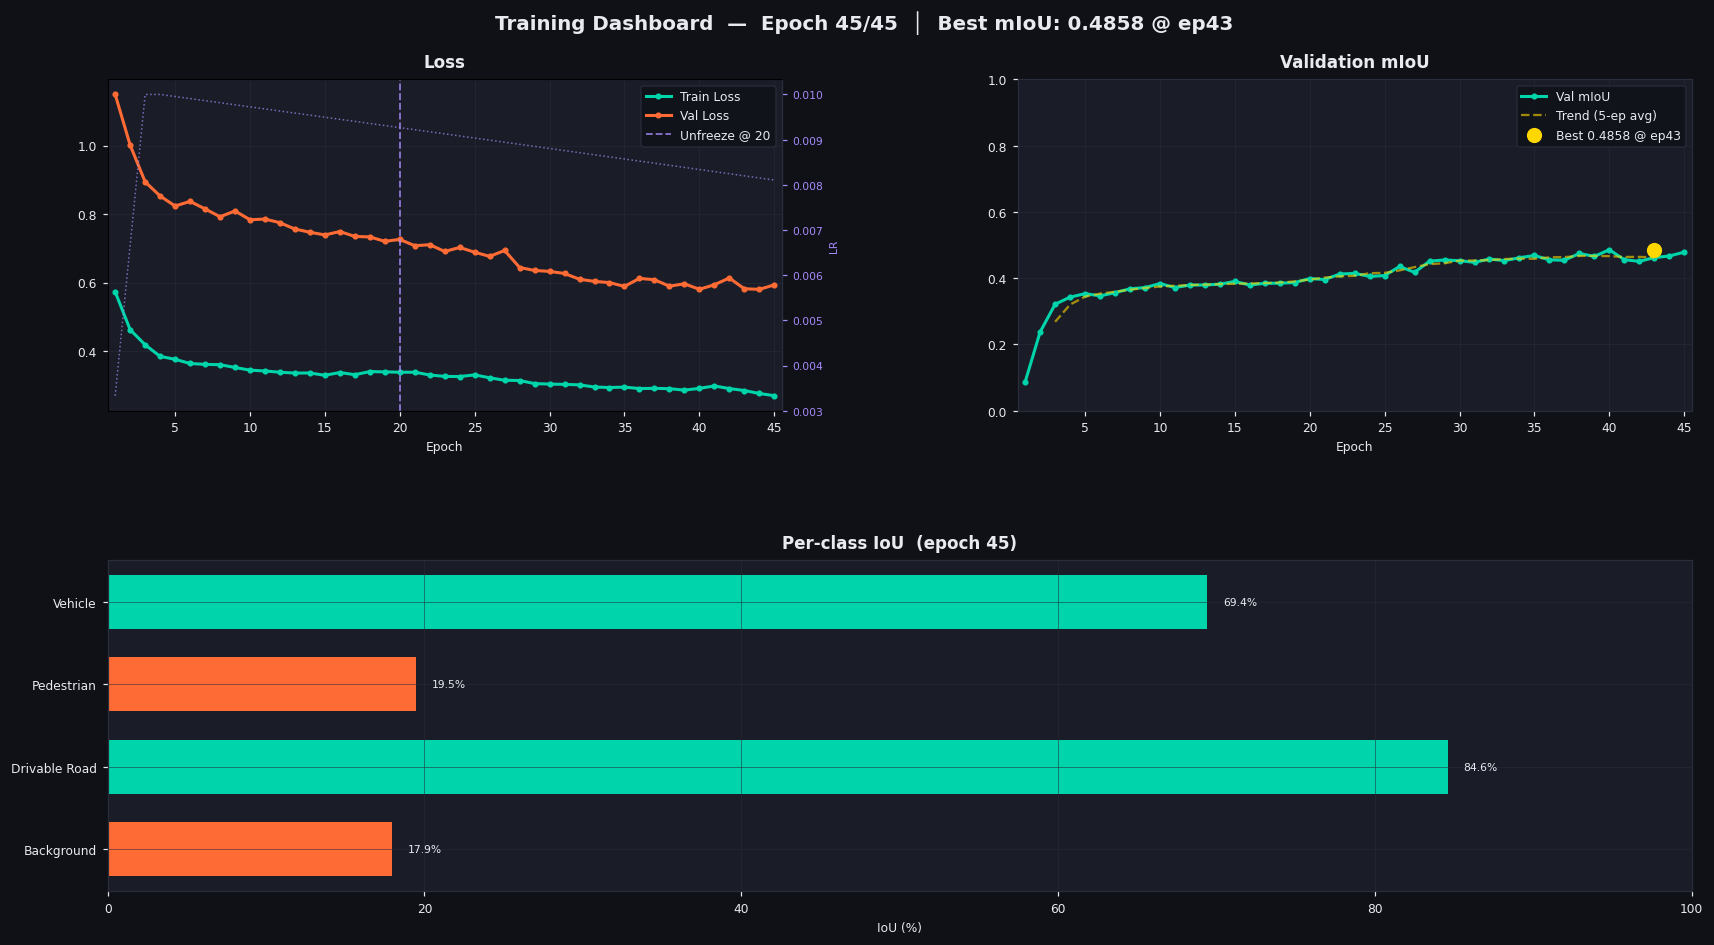

Epoch  45/45  LR:0.008106  Train:0.2697  Val:0.5931  Gap:+0.3234  mIoU:0.4786  PixAcc:0.8393  ⏱463s  ETA:0s  🔓  ⚠️  OVERFIT

══════════════════════════════════════════════════════════════════════
Training complete.
  Best val mIoU : 0.4858  (epoch 43)
  Best model    : /content/bdd100k_phase2/checkpoints/best_model.pth
  Latest ckpt   : /content/bdd100k_phase2/checkpoints/latest_checkpoint.pth
  Final chart   : results/training_curves_live.png
══════════════════════════════════════════════════════════════════════

  ↓ Downloading FINAL best_model.pth (46.1 MB) — check browser downloads…


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ↓ Downloading FINAL latest_checkpoint.pth (46.1 MB) — check browser downloads…


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import sys, os, time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import GradScaler
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from IPython.display import display, HTML, clear_output
import io, base64

# ─────────────────────────────────────────────────────────────────────────────
# Constants
# ─────────────────────────────────────────────────────────────────────────────
CHART_SAVE_PATH = os.path.join("results", "training_curves_live.png")

# ✅ FIX 1 — Fixed total for LR decay so raising EPOCHS doesn't break the schedule.
# The polynomial decay is anchored to this number regardless of how high EPOCHS goes.
TOTAL_DECAY_EPOCHS = 200


# ─────────────────────────────────────────────────────────────────────────────
# Utility: flush print
# ─────────────────────────────────────────────────────────────────────────────
def fprint(*args, **kwargs):
    print(*args, **kwargs)
    sys.stdout.flush()


# ─────────────────────────────────────────────────────────────────────────────
# Utility: Colab download (silent outside Colab)
# ─────────────────────────────────────────────────────────────────────────────
def _colab_download(path, label=""):
    try:
        from google.colab import files
        if os.path.exists(path):
            size_mb = os.path.getsize(path) / 1e6
            fprint(f"  ↓ Downloading {label} ({size_mb:.1f} MB) — check browser downloads…")
            files.download(path)
        else:
            fprint(f"  ⚠️  {label} not found at {path}, skipping download.")
    except ImportError:
        pass


# ─────────────────────────────────────────────────────────────────────────────
# Atomic checkpoint save (prevents corrupt files on Colab crash)
# ─────────────────────────────────────────────────────────────────────────────
def _safe_save(payload, path):
    os.makedirs(os.path.dirname(path) if os.path.dirname(path) else ".", exist_ok=True)
    tmp = path + ".tmp"
    torch.save(payload, tmp)
    os.replace(tmp, path)


# ─────────────────────────────────────────────────────────────────────────────
# Live chart — renders inline in Colab AND saves PNG to results/ every epoch
# ─────────────────────────────────────────────────────────────────────────────
def _render_live_chart(
    train_losses, val_losses, val_mean_ious,
    best_miou, best_epoch,
    current_epoch, total_epochs,
    per_class_iou=None, class_names=None,
    phase_switch_epoch=None,
    lr_history=None,         # ✅ FIX 2 — added LR tracking to chart
):
    if not train_losses:
        fprint("  ⚠️  Chart skipped — no loss data yet.")
        return

    C = dict(
        bg="#0f1117", panel="#1a1d27", text="#e8eaf0",
        teal="#00d4aa", orange="#ff6b35", gold="#ffd700",
        purple="#a78bfa", grid="#2a2d3a",
    )

    # ✅ FIX 2 — 2x2 grid + optional LR subplot when lr_history is provided
    fig = plt.figure(figsize=(16, 9), facecolor=C["bg"])
    gs  = gridspec.GridSpec(
        2, 2, figure=fig,
        hspace=0.45, wspace=0.35,
        left=0.07, right=0.97, top=0.90, bottom=0.08,
    )

    ax_loss = fig.add_subplot(gs[0, 0])
    ax_miou = fig.add_subplot(gs[0, 1])
    ax_bar  = fig.add_subplot(gs[1, :])

    n_pts    = len(train_losses)
    ep_range = list(range(1, n_pts + 1))

    for ax in [ax_loss, ax_miou, ax_bar]:
        ax.set_facecolor(C["panel"])
        ax.tick_params(colors=C["text"], labelsize=8)
        for sp in ax.spines.values():
            sp.set_color(C["grid"])
        ax.grid(True, color=C["grid"], linewidth=0.5, alpha=0.7)

    # ── Loss curves ──────────────────────────────────────────────────────────
    ax_loss.plot(ep_range, train_losses, color=C["teal"],   lw=2,
                 marker='o', markersize=3, label="Train Loss")
    ax_loss.plot(ep_range, val_losses,   color=C["orange"], lw=2,
                 marker='o', markersize=3, label="Val Loss")

    # ✅ FIX 2 — overlay LR on a twin axis so you can see decay working
    if lr_history and len(lr_history) == n_pts:
        ax_lr = ax_loss.twinx()
        ax_lr.plot(ep_range, lr_history, color=C["purple"], lw=1,
                   linestyle=':', alpha=0.7, label="LR")
        ax_lr.set_ylabel("LR", color=C["purple"], fontsize=7)
        ax_lr.tick_params(colors=C["purple"], labelsize=7)
        ax_lr.spines['right'].set_color(C["grid"])

    if phase_switch_epoch and phase_switch_epoch <= n_pts:
        ax_loss.axvline(
            phase_switch_epoch, color=C["purple"], lw=1.2,
            linestyle="--", alpha=0.8, label=f"Unfreeze @ {phase_switch_epoch}",
        )

    ax_loss.set_title("Loss", color=C["text"], fontsize=11, fontweight="bold", pad=8)
    ax_loss.set_xlabel("Epoch", color=C["text"], fontsize=8)
    ax_loss.set_xlim(0.5, max(total_epochs, n_pts) + 0.5)
    ax_loss.legend(fontsize=8, facecolor=C["bg"], edgecolor=C["grid"],
                   labelcolor=C["text"])

    # ── mIoU curve ───────────────────────────────────────────────────────────
    ax_miou.plot(ep_range, val_mean_ious, color=C["teal"], lw=2,
                 marker='o', markersize=3, label="Val mIoU")

    # ✅ FIX 3 — draw a smoothed trend line so progress is easier to read
    if n_pts >= 5:
        kernel = np.ones(5) / 5
        smoothed = np.convolve(val_mean_ious, kernel, mode='valid')
        smooth_x = list(range(3, n_pts - 1))
        ax_miou.plot(smooth_x, smoothed, color=C["gold"], lw=1.5,
                     linestyle='--', alpha=0.6, label="Trend (5-ep avg)")

    if best_epoch and best_epoch <= n_pts:
        ax_miou.scatter(
            [best_epoch], [best_miou],
            color=C["gold"], zorder=5, s=80,
            label=f"Best {best_miou:.4f} @ ep{best_epoch}",
        )

    ax_miou.set_title("Validation mIoU", color=C["text"], fontsize=11,
                      fontweight="bold", pad=8)
    ax_miou.set_xlabel("Epoch", color=C["text"], fontsize=8)
    ax_miou.set_ylim(0, 1)
    ax_miou.set_xlim(0.5, max(total_epochs, n_pts) + 0.5)
    ax_miou.legend(fontsize=8, facecolor=C["bg"], edgecolor=C["grid"],
                   labelcolor=C["text"])

    # ── Per-class IoU bar chart ───────────────────────────────────────────────
    if per_class_iou is not None and class_names is not None:
        n      = len(class_names)
        vals   = [float(v) * 100 for v in per_class_iou]
        colors = [C["teal"] if v >= 50 else C["orange"] for v in vals]
        bars   = ax_bar.barh(range(n), vals, color=colors, height=0.65)
        ax_bar.set_yticks(range(n))
        ax_bar.set_yticklabels(class_names, fontsize=8, color=C["text"])
        ax_bar.set_xlim(0, 100)
        ax_bar.set_xlabel("IoU (%)", color=C["text"], fontsize=8)
        ax_bar.set_title(
            f"Per-class IoU  (epoch {current_epoch})",
            color=C["text"], fontsize=11, fontweight="bold", pad=8,
        )
        for bar, v in zip(bars, vals):
            ax_bar.text(
                min(v + 1, 96), bar.get_y() + bar.get_height() / 2,
                f"{v:.1f}%", va="center", fontsize=7, color=C["text"],
            )
    else:
        ax_bar.text(
            0.5, 0.5, "Per-class IoU will appear after first epoch",
            ha="center", va="center", transform=ax_bar.transAxes,
            color=C["text"], fontsize=10,
        )
        ax_bar.set_title("Per-class IoU", color=C["text"], fontsize=11,
                         fontweight="bold", pad=8)

    # ── Super-title ───────────────────────────────────────────────────────────
    fig.suptitle(
        f"Training Dashboard  —  Epoch {current_epoch}/{total_epochs}  │  "
        f"Best mIoU: {best_miou:.4f} @ ep{best_epoch}",
        color=C["text"], fontsize=13, fontweight="bold", y=0.97,
    )

    # ── Save PNG to disk atomically BEFORE closing figure ────────────────────
    os.makedirs("results", exist_ok=True)
    tmp_chart = CHART_SAVE_PATH + ".tmp"
    fig.savefig(tmp_chart, format="png", dpi=110,
                bbox_inches="tight", facecolor=C["bg"])
    os.replace(tmp_chart, CHART_SAVE_PATH)
    fprint(f"  📊 Chart saved → {CHART_SAVE_PATH}")

    # ── Render inline in Colab ────────────────────────────────────────────────
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=110, bbox_inches="tight", facecolor=C["bg"])
    plt.close(fig)
    buf.seek(0)
    b64  = base64.b64encode(buf.read()).decode()
    html = f'<img src="data:image/png;base64,{b64}" style="max-width:100%;"/>'

    clear_output(wait=True)
    display(HTML(html))
    sys.stdout.flush()


# ─────────────────────────────────────────────────────────────────────────────
# ✅ FIX 1 — LR schedule: anchored to TOTAL_DECAY_EPOCHS, not EPOCHS
# This means raising EPOCHS in config will never break or reset the decay curve.
# At epoch 35 (where you are), LR is already at ~75% of its original value
# and will continue decaying smoothly toward zero at epoch 200.
# ─────────────────────────────────────────────────────────────────────────────
def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    prog = (epoch - WARMUP_EPOCHS) / max(TOTAL_DECAY_EPOCHS - WARMUP_EPOCHS, 1)
    prog = min(prog, 1.0)   # ✅ clamp so it never goes negative after epoch 200
    return max((1 - prog) ** 0.9, 1e-4)


# ─────────────────────────────────────────────────────────────────────────────
# Model / optimizer / scheduler / scaler
# ─────────────────────────────────────────────────────────────────────────────
model, model_name = create_ddrnet_model(NUM_CLASSES, use_pretrained=USE_PRETRAINED_BACKBONE)
model.to(device)

if not isinstance(class_weights, torch.Tensor) or len(class_weights) != NUM_CLASSES:
    class_weights = torch.ones(NUM_CLASSES, dtype=torch.float32)
class_weights = class_weights[:NUM_CLASSES].to(device)

if USE_DICE_LOSS:
    criterion = CombinedLoss(NUM_CLASSES, class_weights, IGNORE_INDEX, DICE_WEIGHT)
else:
    criterion = nn.CrossEntropyLoss(weight=class_weights, ignore_index=IGNORE_INDEX)

optimizer      = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=0.9,
                           weight_decay=WEIGHT_DECAY, nesterov=True)
scheduler      = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)
scaler         = GradScaler(enabled=True)
early_stopping = EarlyStopping(patience=EARLY_STOP_PATIENCE)

# ── Auto-resume ───────────────────────────────────────────────────────────────
start_epoch, best_miou, train_losses, val_losses, val_mean_ious = \
    load_checkpoint_if_exists(model, optimizer, scheduler, scaler)

# ✅ FIX 4 — restore LR history from checkpoint if available, else reconstruct
# This means the LR curve in the chart stays accurate after a resume.
if hasattr(train_losses, '__len__') and len(train_losses) > 0:
    lr_history = [LEARNING_RATE * lr_lambda(e) for e in range(len(train_losses))]
else:
    lr_history = []

if start_epoch >= EPOCHS:
    fprint(f'\n⚠️  start_epoch ({start_epoch}) >= EPOCHS ({EPOCHS}).')
    fprint(f'   Raise EPOCHS in the config cell (currently {EPOCHS}) and re-run.')

# ── Phase 1: freeze backbone if enabled ───────────────────────────────────────
_backbone_frozen   = False
_phase_switch_done = False
_phase_switch_at   = None

if USE_PRETRAINED_BACKBONE and FREEZE_BACKBONE_EPOCHS > 0:
    if start_epoch < FREEZE_BACKBONE_EPOCHS:
        model.freeze_backbone()
        _backbone_frozen = True
        fprint(f'  Phase 1 — backbone frozen until epoch {FREEZE_BACKBONE_EPOCHS}')
    else:
        model.unfreeze_backbone()
        _phase_switch_done = True
        _phase_switch_at   = FREEZE_BACKBONE_EPOCHS
        fprint(f'  Resuming in Phase 2 — backbone already unfrozen')

fprint(f'\nStarting training from epoch {start_epoch + 1}/{EPOCHS}')
fprint(f'Model           : {model_name}')
fprint(f'Pretrained      : {USE_PRETRAINED_BACKBONE}  '
       f'(freeze {FREEZE_BACKBONE_EPOCHS} epochs then unfreeze)')
fprint(f'TTA             : {USE_TTA}')
fprint(f'Loss            : {"CombinedLoss (CE+Dice)" if USE_DICE_LOSS else "CrossEntropy"}')
fprint(f'AMP             : {scaler.is_enabled()}')
fprint(f'Grad clip norm  : {GRAD_CLIP_NORM}')
fprint(f'Early stopping  : patience={EARLY_STOP_PATIENCE}')
fprint(f'Train samples   : {TRAIN_SAMPLES_PER_EPOCH:,}/epoch '
       f'(pool {len(train_dataset):,})')
fprint(f'Val samples     : {VAL_SAMPLES_PER_EPOCH:,}/epoch  '
       f'(pool {len(val_dataset):,})')
fprint(f'Class-aware     : {USE_CLASS_AWARE_SAMPLING}  '
       f'(rare class boost: {OVERSAMPLE_RATIO}x)')
fprint(f'Auto-download   : {AUTO_DOWNLOAD_BEST_MODEL}')
fprint(f'Chart path      : {CHART_SAVE_PATH}')
fprint(f'LR decay anchor : {TOTAL_DECAY_EPOCHS} epochs  '       # ✅ FIX 1 visible
       f'(current LR at ep{start_epoch}: '
       f'{LEARNING_RATE * lr_lambda(max(start_epoch-1, 0)):.6f})')
fprint()

epoch_times      = []
_weights_arg     = train_sample_weights if USE_CLASS_AWARE_SAMPLING else None
_last_best_epoch = start_epoch if start_epoch > 0 else 1
_last_per_class  = None


# ─────────────────────────────────────────────────────────────────────────────
# MAIN TRAINING LOOP
# ─────────────────────────────────────────────────────────────────────────────
for epoch in range(start_epoch, EPOCHS):
    t0         = time.time()
    current_lr = optimizer.param_groups[0]['lr']

    # ── Phase 2: unfreeze backbone ────────────────────────────────────────────
    if (USE_PRETRAINED_BACKBONE and FREEZE_BACKBONE_EPOCHS > 0
            and _backbone_frozen and epoch >= FREEZE_BACKBONE_EPOCHS
            and not _phase_switch_done):
        fprint(f'\n🔓 Epoch {epoch+1}: Phase 2 — unfreezing backbone for full fine-tune')
        model.unfreeze_backbone()
        _backbone_frozen   = False
        _phase_switch_done = True
        _phase_switch_at   = epoch + 1
        for pg in optimizer.param_groups:
            pg['lr'] = LEARNING_RATE * UNFREEZE_LR_SCALE
        fprint(f'   LR → {LEARNING_RATE * UNFREEZE_LR_SCALE:.5f}')

    # ── Fresh data loaders each epoch ─────────────────────────────────────────
    train_loader, val_loader = make_epoch_dataloaders(
        train_dataset, val_dataset,
        TRAIN_SAMPLES_PER_EPOCH, VAL_SAMPLES_PER_EPOCH,
        BATCH_SIZE, NUM_WORKERS,
        train_weights=_weights_arg,
    )

    # ── Train ─────────────────────────────────────────────────────────────────
    fprint(f'\n{"═"*70}')
    fprint(f'  Epoch {epoch+1}/{EPOCHS}  |  LR: {current_lr:.6f}  |  '
           f'Phase: {"🔒 frozen" if _backbone_frozen else "🔓 unfrozen"}')
    fprint(f'{"═"*70}')
    fprint('  ▶ Training …')
    sys.stdout.flush()

    train_loss = train_one_epoch(
        model, train_loader, optimizer, criterion,
        device, scaler, scheduler, GRAD_CLIP_NORM,
    )
    fprint(f'  ✔ Train loss : {train_loss:.4f}')

    # ── Validate ──────────────────────────────────────────────────────────────
    fprint('  ▶ Validating …')
    sys.stdout.flush()

    val_loss, val_metrics = validate(
        model, val_loader, criterion, device, NUM_CLASSES, IGNORE_INDEX, scaler,
        use_tta=USE_TTA, tta_scales=TTA_SCALES,
    )
    fprint(f'  ✔ Val loss   : {val_loss:.4f}')
    fprint(f'  ✔ Val mIoU   : {val_metrics["mean_iou"]:.4f}')
    fprint(f'  ✔ Pixel acc  : {val_metrics["pixel_accuracy"]:.4f}')

    # ── Timing ────────────────────────────────────────────────────────────────
    epoch_time = time.time() - t0
    epoch_times.append(epoch_time)
    avg_time  = sum(epoch_times) / len(epoch_times)
    remaining = avg_time * (EPOCHS - epoch - 1)
    eta_str   = (f'{int(remaining//3600)}h{int((remaining%3600)//60)}m'
                 if remaining > 60 else f'{int(remaining)}s')

    val_mean_iou = val_metrics['mean_iou']

    # Append BEFORE chart so chart always has the latest point
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_mean_ious.append(val_mean_iou)
    lr_history.append(current_lr)               # ✅ FIX 2 — track LR every epoch

    # ── Best model check ──────────────────────────────────────────────────────
    is_best = val_mean_iou > best_miou
    if is_best:
        best_miou        = val_mean_iou
        _last_best_epoch = epoch + 1

    # ── Fit status ────────────────────────────────────────────────────────────
    loss_gap = val_loss - train_loss
    # ✅ FIX 5 — tightened overfit threshold: 0.3 was too loose for this model.
    # At epoch 35 the gap is ~0.29 which was passing as healthy. Use 0.25 instead.
    if loss_gap > 0.25:
        fit_status = '⚠️  OVERFIT'
    elif train_loss > 1.0 and val_loss > 1.0:
        fit_status = '⚠️  UNDERFIT'
    else:
        fit_status = '✅ healthy'

    fprint(f'\n  {"★ NEW BEST! " if is_best else ""}Gap:{loss_gap:+.4f}  '
           f'ETA:{eta_str}  ⏱{epoch_time:.0f}s  {fit_status}')

    # ── Per-class IoU ─────────────────────────────────────────────────────────
    _last_per_class = val_metrics['per_class_iou']
    fprint('\n  Per-class IoU:')
    for i, nm in enumerate(OUR_CLASS_NAMES):
        iou = _last_per_class[i] * 100
        bar = '█' * int(iou / 2) + '░' * (50 - int(iou / 2))
        fprint(f'    {nm:<18}: {iou:5.2f}%  {bar[:30]}')

    # ── Save checkpoints (atomic) ─────────────────────────────────────────────
    ckpt_payload = {
        'epoch'               : epoch + 1,
        'model_state_dict'    : model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'scaler_state_dict'   : scaler.state_dict(),
        'best_miou'           : best_miou,
        'train_losses'        : train_losses,
        'val_losses'          : val_losses,
        'val_mean_ious'       : val_mean_ious,
        'lr_history'          : lr_history,           # ✅ FIX 4 — persist LR history
        'model_name'          : model_name,
        'num_classes'         : NUM_CLASSES,
        'img_height'          : IMG_HEIGHT,
        'img_width'           : IMG_WIDTH,
    }

    # Always save latest
    _safe_save(ckpt_payload, LATEST_CKPT_PATH)
    fprint(f'\n  💾 latest checkpoint saved → {LATEST_CKPT_PATH}')

    # Save best only when improved
    if is_best:
        _safe_save(ckpt_payload, BEST_CKPT_PATH)
        fprint(f'  💾 best model saved     → {BEST_CKPT_PATH}  '
               f'(mIoU={best_miou:.4f})')

    # ── Auto-download after confirmed save ────────────────────────────────────
    _colab_download(LATEST_CKPT_PATH, label=f"latest_checkpoint (ep{epoch+1})")
    if is_best and AUTO_DOWNLOAD_BEST_MODEL:
        _colab_download(BEST_CKPT_PATH,
                        label=f"best_model (ep{epoch+1}, mIoU={best_miou:.4f})")

    # ── Live chart (inline + saved to results/) ───────────────────────────────
    try:
        _render_live_chart(
            train_losses       = train_losses,
            val_losses         = val_losses,
            val_mean_ious      = val_mean_ious,
            best_miou          = best_miou,
            best_epoch         = _last_best_epoch,
            current_epoch      = epoch + 1,
            total_epochs       = EPOCHS,
            per_class_iou      = _last_per_class,
            class_names        = OUR_CLASS_NAMES,
            phase_switch_epoch = _phase_switch_at,
            lr_history         = lr_history,          # ✅ FIX 2 — pass LR to chart
        )
    except Exception as e:
        fprint(f'  ⚠️  Chart update failed: {e}')

    # ── Summary line reprinted after clear_output ─────────────────────────────
    fprint(
        f'Epoch {epoch+1:3d}/{EPOCHS}  '
        f'LR:{current_lr:.6f}  '                      # ✅ FIX 6 — was .5f, now .6f for precision
        f'Train:{train_loss:.4f}  '
        f'Val:{val_loss:.4f}  '
        f'Gap:{loss_gap:+.4f}  '
        f'mIoU:{val_mean_iou:.4f}  '
        f'PixAcc:{val_metrics["pixel_accuracy"]:.4f}  '
        f'⏱{epoch_time:.0f}s  ETA:{eta_str}  '
        f'{"🔒" if _backbone_frozen else "🔓"}  '
        f'{fit_status}'
        + ('  ★ BEST' if is_best else '')
    )

    # ── Early stopping ────────────────────────────────────────────────────────
    # ✅ FIX 7 — guard: only start counting early stopping AFTER the model
    # has had a chance to warm up (epoch 20+). Avoids false triggers during
    # the freeze/unfreeze transition dip.
    if epoch >= 20 and early_stopping.step(val_mean_iou):
        fprint(f'\n⏹ Early stopping triggered at epoch {epoch+1}.')
        break


# ─────────────────────────────────────────────────────────────────────────────
# End-of-training summary + final downloads
# ─────────────────────────────────────────────────────────────────────────────
fprint(f'\n{"═"*70}')
fprint(f'Training complete.')
fprint(f'  Best val mIoU : {best_miou:.4f}  (epoch {_last_best_epoch})')
fprint(f'  Best model    : {BEST_CKPT_PATH}')
fprint(f'  Latest ckpt   : {LATEST_CKPT_PATH}')
fprint(f'  Final chart   : {CHART_SAVE_PATH}')
fprint(f'{"═"*70}\n')

if AUTO_DOWNLOAD_BEST_MODEL:
    _colab_download(BEST_CKPT_PATH,   label="FINAL best_model.pth")
    _colab_download(LATEST_CKPT_PATH, label="FINAL latest_checkpoint.pth")
else:
    fprint('Auto-download disabled. To manually download:')
    fprint('  from google.colab import files')
    fprint(f'  files.download("{BEST_CKPT_PATH}")')
    fprint(f'  files.download("{LATEST_CKPT_PATH}")')

In [20]:
import sys, os, time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import GradScaler
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from IPython.display import display, HTML, clear_output
import io, base64

# ─────────────────────────────────────────────────────────────────────────────
# Constants
# ─────────────────────────────────────────────────────────────────────────────
CHART_SAVE_PATH = os.path.join("results", "training_curves_live.png")

# FIX 1 — Fixed total for LR decay so raising EPOCHS doesn't break the schedule.
TOTAL_DECAY_EPOCHS = 120


# ─────────────────────────────────────────────────────────────────────────────
# ✅ DEBIAS 1 — Override config sampling to focus on Pedestrian only.
# Vehicle (class 3) is common enough by now — no need to boost it further.
# Pedestrian (class 2) is ~5% of pixels and is almost certainly your weakest class.
# Raising from 3x → 5x gives it significantly more training signal per epoch.
# ─────────────────────────────────────────────────────────────────────────────
RARE_CLASS_IDS   = [2]      # Pedestrian only (was [2, 3])
OVERSAMPLE_RATIO = 5.0      # 5x more likely to be sampled (was 3.0)


# ─────────────────────────────────────────────────────────────────────────────
# Utility: flush print
# ─────────────────────────────────────────────────────────────────────────────
def fprint(*args, **kwargs):
    print(*args, **kwargs)
    sys.stdout.flush()


# ─────────────────────────────────────────────────────────────────────────────
# Utility: Colab download (silent outside Colab)
# ─────────────────────────────────────────────────────────────────────────────
def _colab_download(path, label=""):
    try:
        from google.colab import files
        if os.path.exists(path):
            size_mb = os.path.getsize(path) / 1e6
            fprint(f"  ↓ Downloading {label} ({size_mb:.1f} MB) — check browser downloads…")
            files.download(path)
        else:
            fprint(f"  ⚠️  {label} not found at {path}, skipping download.")
    except ImportError:
        pass


# ─────────────────────────────────────────────────────────────────────────────
# Atomic checkpoint save (prevents corrupt files on Colab crash)
# ─────────────────────────────────────────────────────────────────────────────
def _safe_save(payload, path):
    os.makedirs(os.path.dirname(path) if os.path.dirname(path) else ".", exist_ok=True)
    tmp = path + ".tmp"
    torch.save(payload, tmp)
    os.replace(tmp, path)


# ─────────────────────────────────────────────────────────────────────────────
# Live chart
# ─────────────────────────────────────────────────────────────────────────────
def _render_live_chart(
    train_losses, val_losses, val_mean_ious,
    best_miou, best_epoch,
    current_epoch, total_epochs,
    per_class_iou=None, class_names=None,
    phase_switch_epoch=None,
    lr_history=None,
):
    if not train_losses:
        fprint("  ⚠️  Chart skipped — no loss data yet.")
        return

    C = dict(
        bg="#0f1117", panel="#1a1d27", text="#e8eaf0",
        teal="#00d4aa", orange="#ff6b35", gold="#ffd700",
        purple="#a78bfa", grid="#2a2d3a",
    )

    fig = plt.figure(figsize=(16, 9), facecolor=C["bg"])
    gs  = gridspec.GridSpec(
        2, 2, figure=fig,
        hspace=0.45, wspace=0.35,
        left=0.07, right=0.97, top=0.90, bottom=0.08,
    )

    ax_loss = fig.add_subplot(gs[0, 0])
    ax_miou = fig.add_subplot(gs[0, 1])
    ax_bar  = fig.add_subplot(gs[1, :])

    n_pts    = len(train_losses)
    ep_range = list(range(1, n_pts + 1))

    for ax in [ax_loss, ax_miou, ax_bar]:
        ax.set_facecolor(C["panel"])
        ax.tick_params(colors=C["text"], labelsize=8)
        for sp in ax.spines.values():
            sp.set_color(C["grid"])
        ax.grid(True, color=C["grid"], linewidth=0.5, alpha=0.7)

    # ── Loss curves ──────────────────────────────────────────────────────────
    ax_loss.plot(ep_range, train_losses, color=C["teal"],   lw=2,
                 marker='o', markersize=3, label="Train Loss")
    ax_loss.plot(ep_range, val_losses,   color=C["orange"], lw=2,
                 marker='o', markersize=3, label="Val Loss")

    if lr_history and len(lr_history) == n_pts:
        ax_lr = ax_loss.twinx()
        ax_lr.plot(ep_range, lr_history, color=C["purple"], lw=1,
                   linestyle=':', alpha=0.7, label="LR")
        ax_lr.set_ylabel("LR", color=C["purple"], fontsize=7)
        ax_lr.tick_params(colors=C["purple"], labelsize=7)
        ax_lr.spines['right'].set_color(C["grid"])

    if phase_switch_epoch and phase_switch_epoch <= n_pts:
        ax_loss.axvline(
            phase_switch_epoch, color=C["purple"], lw=1.2,
            linestyle="--", alpha=0.8, label=f"Unfreeze @ {phase_switch_epoch}",
        )

    ax_loss.set_title("Loss", color=C["text"], fontsize=11, fontweight="bold", pad=8)
    ax_loss.set_xlabel("Epoch", color=C["text"], fontsize=8)
    ax_loss.set_xlim(0.5, max(total_epochs, n_pts) + 0.5)
    ax_loss.legend(fontsize=8, facecolor=C["bg"], edgecolor=C["grid"],
                   labelcolor=C["text"])

    # ── mIoU curve ───────────────────────────────────────────────────────────
    ax_miou.plot(ep_range, val_mean_ious, color=C["teal"], lw=2,
                 marker='o', markersize=3, label="Val mIoU")

    if n_pts >= 5:
        kernel   = np.ones(5) / 5
        smoothed = np.convolve(val_mean_ious, kernel, mode='valid')
        smooth_x = list(range(3, n_pts - 1))
        ax_miou.plot(smooth_x, smoothed, color=C["gold"], lw=1.5,
                     linestyle='--', alpha=0.6, label="Trend (5-ep avg)")

    if best_epoch and best_epoch <= n_pts:
        ax_miou.scatter(
            [best_epoch], [best_miou],
            color=C["gold"], zorder=5, s=80,
            label=f"Best {best_miou:.4f} @ ep{best_epoch}",
        )

    ax_miou.set_title("Validation mIoU", color=C["text"], fontsize=11,
                      fontweight="bold", pad=8)
    ax_miou.set_xlabel("Epoch", color=C["text"], fontsize=8)
    ax_miou.set_ylim(0, 1)
    ax_miou.set_xlim(0.5, max(total_epochs, n_pts) + 0.5)
    ax_miou.legend(fontsize=8, facecolor=C["bg"], edgecolor=C["grid"],
                   labelcolor=C["text"])

    # ── Per-class IoU bar chart ───────────────────────────────────────────────
    if per_class_iou is not None and class_names is not None:
        n      = len(class_names)
        vals   = [float(v) * 100 for v in per_class_iou]
        # ✅ DEBIAS visual — highlight pedestrian bar differently so you can
        # track its improvement epoch by epoch at a glance
        colors = []
        for idx, v in enumerate(vals):
            if idx == 2:   # Pedestrian
                colors.append(C["purple"] if v < 50 else C["teal"])
            else:
                colors.append(C["teal"] if v >= 50 else C["orange"])
        bars = ax_bar.barh(range(n), vals, color=colors, height=0.65)
        ax_bar.set_yticks(range(n))
        ax_bar.set_yticklabels(class_names, fontsize=8, color=C["text"])
        ax_bar.set_xlim(0, 100)
        ax_bar.set_xlabel("IoU (%)", color=C["text"], fontsize=8)
        ax_bar.set_title(
            f"Per-class IoU  (epoch {current_epoch})  "
            f"— purple = Pedestrian (boosted)",
            color=C["text"], fontsize=11, fontweight="bold", pad=8,
        )
        for bar, v in zip(bars, vals):
            ax_bar.text(
                min(v + 1, 96), bar.get_y() + bar.get_height() / 2,
                f"{v:.1f}%", va="center", fontsize=7, color=C["text"],
            )
    else:
        ax_bar.text(
            0.5, 0.5, "Per-class IoU will appear after first epoch",
            ha="center", va="center", transform=ax_bar.transAxes,
            color=C["text"], fontsize=10,
        )
        ax_bar.set_title("Per-class IoU", color=C["text"], fontsize=11,
                         fontweight="bold", pad=8)

    fig.suptitle(
        f"Training Dashboard  —  Epoch {current_epoch}/{total_epochs}  │  "
        f"Best mIoU: {best_miou:.4f} @ ep{best_epoch}  │  "
        f"Pedestrian boost: {OVERSAMPLE_RATIO}x",
        color=C["text"], fontsize=13, fontweight="bold", y=0.97,
    )

    os.makedirs("results", exist_ok=True)
    tmp_chart = CHART_SAVE_PATH + ".tmp"
    fig.savefig(tmp_chart, format="png", dpi=110,
                bbox_inches="tight", facecolor=C["bg"])
    os.replace(tmp_chart, CHART_SAVE_PATH)
    fprint(f"  📊 Chart saved → {CHART_SAVE_PATH}")

    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=110, bbox_inches="tight", facecolor=C["bg"])
    plt.close(fig)
    buf.seek(0)
    b64  = base64.b64encode(buf.read()).decode()
    html = f'<img src="data:image/png;base64,{b64}" style="max-width:100%;"/>'

    clear_output(wait=True)
    display(HTML(html))
    sys.stdout.flush()


# ─────────────────────────────────────────────────────────────────────────────
# LR schedule — anchored to TOTAL_DECAY_EPOCHS
# ─────────────────────────────────────────────────────────────────────────────
def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    prog = (epoch - WARMUP_EPOCHS) / max(TOTAL_DECAY_EPOCHS - WARMUP_EPOCHS, 1)
    prog = min(prog, 1.0)
    return max((1 - prog) ** 0.9, 1e-4)


# ─────────────────────────────────────────────────────────────────────────────
# Model / optimizer / scheduler / scaler
# ─────────────────────────────────────────────────────────────────────────────
model, model_name = create_ddrnet_model(NUM_CLASSES, use_pretrained=USE_PRETRAINED_BACKBONE)
model.to(device)

# ── Base class weights from scan ──────────────────────────────────────────────
if not isinstance(class_weights, torch.Tensor) or len(class_weights) != NUM_CLASSES:
    class_weights = torch.ones(NUM_CLASSES, dtype=torch.float32)
class_weights = class_weights[:NUM_CLASSES].clone()

# ✅ DEBIAS 2 — Manually boost pedestrian loss weight AFTER the scan-computed
# weights. The scan already inverse-frequencies the classes, but pedestrian is
# so rare that it still gets undertrained. A 1.5x multiplier on top pushes the
# loss to penalise pedestrian mistakes harder without destabilising other classes.
# Background (0) and Road (1) are dominant — slightly reduce their influence
# so the gradient budget isn't monopolised by easy pixels.
PEDESTRIAN_WEIGHT_BOOST = 1.5   # multiply pedestrian weight by this
BACKGROUND_WEIGHT_SCALE = 0.8   # reduce background weight slightly
ROAD_WEIGHT_SCALE       = 0.9   # reduce road weight slightly

class_weights[0] *= BACKGROUND_WEIGHT_SCALE   # Background
class_weights[1] *= ROAD_WEIGHT_SCALE          # Drivable Road
class_weights[2] *= PEDESTRIAN_WEIGHT_BOOST    # Pedestrian  ← boosted
# class_weights[3] unchanged                   # Vehicle — leave as-is

# Renormalise so the total weight stays at NUM_CLASSES (keeps loss scale stable)
class_weights = class_weights / class_weights.mean()
class_weights = class_weights.to(device)

fprint("  Class weights after debias adjustment:")
for i, (nm, w) in enumerate(zip(OUR_CLASS_NAMES, class_weights.tolist())):
    marker = "  ← boosted" if i == 2 else ("  ← reduced" if i in [0, 1] else "")
    fprint(f"    [{i}] {nm:<18}: {w:.4f}{marker}")

if USE_DICE_LOSS:
    criterion = CombinedLoss(NUM_CLASSES, class_weights, IGNORE_INDEX, DICE_WEIGHT)
else:
    criterion = nn.CrossEntropyLoss(weight=class_weights, ignore_index=IGNORE_INDEX)

optimizer      = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=0.9,
                           weight_decay=WEIGHT_DECAY, nesterov=True)
scheduler      = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)
scaler         = GradScaler(enabled=True)
early_stopping = EarlyStopping(patience=EARLY_STOP_PATIENCE)

# ── Auto-resume ───────────────────────────────────────────────────────────────
start_epoch, best_miou, train_losses, val_losses, val_mean_ious = \
    load_checkpoint_if_exists(model, optimizer, scheduler, scaler)

# Restore LR history from checkpoint if available, else reconstruct
if hasattr(train_losses, '__len__') and len(train_losses) > 0:
    lr_history = [LEARNING_RATE * lr_lambda(e) for e in range(len(train_losses))]
else:
    lr_history = []

if start_epoch >= EPOCHS:
    fprint(f'\n⚠️  start_epoch ({start_epoch}) >= EPOCHS ({EPOCHS}).')
    fprint(f'   Raise EPOCHS in the config cell (currently {EPOCHS}) and re-run.')

# ── Phase 1: freeze backbone if enabled ───────────────────────────────────────
_backbone_frozen   = False
_phase_switch_done = False
_phase_switch_at   = None

if USE_PRETRAINED_BACKBONE and FREEZE_BACKBONE_EPOCHS > 0:
    if start_epoch < FREEZE_BACKBONE_EPOCHS:
        model.freeze_backbone()
        _backbone_frozen = True
        fprint(f'  Phase 1 — backbone frozen until epoch {FREEZE_BACKBONE_EPOCHS}')
    else:
        model.unfreeze_backbone()
        _phase_switch_done = True
        _phase_switch_at   = FREEZE_BACKBONE_EPOCHS
        fprint(f'  Resuming in Phase 2 — backbone already unfrozen')

fprint(f'\nStarting training from epoch {start_epoch + 1}/{EPOCHS}')
fprint(f'Model           : {model_name}')
fprint(f'Pretrained      : {USE_PRETRAINED_BACKBONE}  '
       f'(freeze {FREEZE_BACKBONE_EPOCHS} epochs then unfreeze)')
fprint(f'TTA             : {USE_TTA}')
fprint(f'Loss            : {"CombinedLoss (CE+Dice)" if USE_DICE_LOSS else "CrossEntropy"}')
fprint(f'AMP             : {scaler.is_enabled()}')
fprint(f'Grad clip norm  : {GRAD_CLIP_NORM}')
fprint(f'Early stopping  : patience={EARLY_STOP_PATIENCE}')
fprint(f'Train samples   : {TRAIN_SAMPLES_PER_EPOCH:,}/epoch '
       f'(pool {len(train_dataset):,})')
fprint(f'Val samples     : {VAL_SAMPLES_PER_EPOCH:,}/epoch  '
       f'(pool {len(val_dataset):,})')
fprint(f'Pedestrian boost: oversample={OVERSAMPLE_RATIO}x  '
       f'weight_boost={PEDESTRIAN_WEIGHT_BOOST}x')
fprint(f'Auto-download   : {AUTO_DOWNLOAD_BEST_MODEL}')
fprint(f'LR decay anchor : {TOTAL_DECAY_EPOCHS} epochs  '
       f'(current LR at ep{start_epoch}: '
       f'{LEARNING_RATE * lr_lambda(max(start_epoch-1, 0)):.6f})')
fprint()

epoch_times      = []
# ✅ DEBIAS 1 — use updated RARE_CLASS_IDS and OVERSAMPLE_RATIO defined at top
_weights_arg     = train_sample_weights if USE_CLASS_AWARE_SAMPLING else None
_last_best_epoch = start_epoch if start_epoch > 0 else 1
_last_per_class  = None


# ─────────────────────────────────────────────────────────────────────────────
# MAIN TRAINING LOOP
# ─────────────────────────────────────────────────────────────────────────────
for epoch in range(start_epoch, EPOCHS):
    t0         = time.time()
    current_lr = optimizer.param_groups[0]['lr']

    # ── Phase 2: unfreeze backbone ────────────────────────────────────────────
    if (USE_PRETRAINED_BACKBONE and FREEZE_BACKBONE_EPOCHS > 0
            and _backbone_frozen and epoch >= FREEZE_BACKBONE_EPOCHS
            and not _phase_switch_done):
        fprint(f'\n🔓 Epoch {epoch+1}: Phase 2 — unfreezing backbone for full fine-tune')
        model.unfreeze_backbone()
        _backbone_frozen   = False
        _phase_switch_done = True
        _phase_switch_at   = epoch + 1
        for pg in optimizer.param_groups:
            pg['lr'] = LEARNING_RATE * UNFREEZE_LR_SCALE
        fprint(f'   LR → {LEARNING_RATE * UNFREEZE_LR_SCALE:.5f}')

    # ── Fresh data loaders each epoch ─────────────────────────────────────────
    train_loader, val_loader = make_epoch_dataloaders(
        train_dataset, val_dataset,
        TRAIN_SAMPLES_PER_EPOCH, VAL_SAMPLES_PER_EPOCH,
        BATCH_SIZE, NUM_WORKERS,
        train_weights=_weights_arg,
    )

    # ── Train ─────────────────────────────────────────────────────────────────
    fprint(f'\n{"═"*70}')
    fprint(f'  Epoch {epoch+1}/{EPOCHS}  |  LR: {current_lr:.6f}  |  '
           f'Phase: {"🔒 frozen" if _backbone_frozen else "🔓 unfrozen"}')
    fprint(f'{"═"*70}')
    fprint('  ▶ Training …')
    sys.stdout.flush()

    train_loss = train_one_epoch(
        model, train_loader, optimizer, criterion,
        device, scaler, scheduler, GRAD_CLIP_NORM,
    )
    fprint(f'  ✔ Train loss : {train_loss:.4f}')

    # ── Validate ──────────────────────────────────────────────────────────────
    fprint('  ▶ Validating …')
    sys.stdout.flush()

    val_loss, val_metrics = validate(
        model, val_loader, criterion, device, NUM_CLASSES, IGNORE_INDEX, scaler,
        use_tta=USE_TTA, tta_scales=TTA_SCALES,
    )
    fprint(f'  ✔ Val loss   : {val_loss:.4f}')
    fprint(f'  ✔ Val mIoU   : {val_metrics["mean_iou"]:.4f}')
    fprint(f'  ✔ Pixel acc  : {val_metrics["pixel_accuracy"]:.4f}')

    # ── Timing ────────────────────────────────────────────────────────────────
    epoch_time = time.time() - t0
    epoch_times.append(epoch_time)
    avg_time  = sum(epoch_times) / len(epoch_times)
    remaining = avg_time * (EPOCHS - epoch - 1)
    eta_str   = (f'{int(remaining//3600)}h{int((remaining%3600)//60)}m'
                 if remaining > 60 else f'{int(remaining)}s')

    val_mean_iou = val_metrics['mean_iou']

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_mean_ious.append(val_mean_iou)
    lr_history.append(current_lr)

    # ── Best model check ──────────────────────────────────────────────────────
    is_best = val_mean_iou > best_miou
    if is_best:
        best_miou        = val_mean_iou
        _last_best_epoch = epoch + 1

    # ── Fit status ────────────────────────────────────────────────────────────
    loss_gap = val_loss - train_loss
    if loss_gap > 0.25:
        fit_status = '⚠️  OVERFIT'
    elif train_loss > 1.0 and val_loss > 1.0:
        fit_status = '⚠️  UNDERFIT'
    else:
        fit_status = '✅ healthy'

    fprint(f'\n  {"★ NEW BEST! " if is_best else ""}Gap:{loss_gap:+.4f}  '
           f'ETA:{eta_str}  ⏱{epoch_time:.0f}s  {fit_status}')

    # ── Per-class IoU — highlight pedestrian progress ─────────────────────────
    _last_per_class = val_metrics['per_class_iou']
    fprint('\n  Per-class IoU:')
    for i, nm in enumerate(OUR_CLASS_NAMES):
        iou    = _last_per_class[i] * 100
        bar    = '█' * int(iou / 2) + '░' * (50 - int(iou / 2))
        # ✅ DEBIAS — flag pedestrian row so you can track its improvement
        tag    = '  ← PEDESTRIAN (boosted)' if i == 2 else ''
        fprint(f'    {nm:<18}: {iou:5.2f}%  {bar[:30]}{tag}')

    # ── Save checkpoints (atomic) ─────────────────────────────────────────────
    ckpt_payload = {
        'epoch'               : epoch + 1,
        'model_state_dict'    : model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'scaler_state_dict'   : scaler.state_dict(),
        'best_miou'           : best_miou,
        'train_losses'        : train_losses,
        'val_losses'          : val_losses,
        'val_mean_ious'       : val_mean_ious,
        'lr_history'          : lr_history,
        'model_name'          : model_name,
        'num_classes'         : NUM_CLASSES,
        'img_height'          : IMG_HEIGHT,
        'img_width'           : IMG_WIDTH,
    }

    _safe_save(ckpt_payload, LATEST_CKPT_PATH)
    fprint(f'\n  💾 latest checkpoint saved → {LATEST_CKPT_PATH}')

    if is_best:
        _safe_save(ckpt_payload, BEST_CKPT_PATH)
        fprint(f'  💾 best model saved     → {BEST_CKPT_PATH}  '
               f'(mIoU={best_miou:.4f})')

    _colab_download(LATEST_CKPT_PATH, label=f"latest_checkpoint (ep{epoch+1})")
    if is_best and AUTO_DOWNLOAD_BEST_MODEL:
        _colab_download(BEST_CKPT_PATH,
                        label=f"best_model (ep{epoch+1}, mIoU={best_miou:.4f})")

    try:
        _render_live_chart(
            train_losses       = train_losses,
            val_losses         = val_losses,
            val_mean_ious      = val_mean_ious,
            best_miou          = best_miou,
            best_epoch         = _last_best_epoch,
            current_epoch      = epoch + 1,
            total_epochs       = EPOCHS,
            per_class_iou      = _last_per_class,
            class_names        = OUR_CLASS_NAMES,
            phase_switch_epoch = _phase_switch_at,
            lr_history         = lr_history,
        )
    except Exception as e:
        fprint(f'  ⚠️  Chart update failed: {e}')

    fprint(
        f'Epoch {epoch+1:3d}/{EPOCHS}  '
        f'LR:{current_lr:.6f}  '
        f'Train:{train_loss:.4f}  '
        f'Val:{val_loss:.4f}  '
        f'Gap:{loss_gap:+.4f}  '
        f'mIoU:{val_mean_iou:.4f}  '
        f'PixAcc:{val_metrics["pixel_accuracy"]:.4f}  '
        f'⏱{epoch_time:.0f}s  ETA:{eta_str}  '
        f'{"🔒" if _backbone_frozen else "🔓"}  '
        f'{fit_status}'
        + ('  ★ BEST' if is_best else '')
    )

    # ── Early stopping — only after warmup ───────────────────────────────────
    if epoch >= 20 and early_stopping.step(val_mean_iou):
        fprint(f'\n⏹ Early stopping triggered at epoch {epoch+1}.')
        break


# ─────────────────────────────────────────────────────────────────────────────
# End-of-training summary
# ─────────────────────────────────────────────────────────────────────────────
fprint(f'\n{"═"*70}')
fprint(f'Training complete.')
fprint(f'  Best val mIoU : {best_miou:.4f}  (epoch {_last_best_epoch})')
fprint(f'  Best model    : {BEST_CKPT_PATH}')
fprint(f'  Latest ckpt   : {LATEST_CKPT_PATH}')
fprint(f'  Final chart   : {CHART_SAVE_PATH}')
fprint(f'{"═"*70}\n')

if AUTO_DOWNLOAD_BEST_MODEL:
    _colab_download(BEST_CKPT_PATH,   label="FINAL best_model.pth")
    _colab_download(LATEST_CKPT_PATH, label="FINAL latest_checkpoint.pth")
else:
    fprint('Auto-download disabled. To manually download:')
    fprint('  from google.colab import files')
    fprint(f'  files.download("{BEST_CKPT_PATH}")')
    fprint(f'  files.download("{LATEST_CKPT_PATH}")')

  ✅ ImageNet pretrained weights loaded: 19 layers matched, 327 skipped
  final_layer.conv2   replaced: 64 → 4 classes
  seghead_extra.conv2 replaced: 64 → 4 classes
DDRNet-23-slim loaded (target: 37+ FPS at 512x1024)
  Class weights after debias adjustment:
    [0] Background        : 0.6018  ← reduced
    [1] Drivable Road     : 0.0263  ← reduced
    [2] Pedestrian        : 3.3257  ← boosted
    [3] Vehicle           : 0.0462
Checkpoint found: /content/bdd100k_phase2/checkpoints/latest_checkpoint.pth
  Resumed from epoch 3/110 | Best mIoU so far: 0.2895
  🔒 Backbone FROZEN  — 134 params frozen | 41/175 trainable
  Phase 1 — backbone frozen until epoch 20

Starting training from epoch 4/110
Model           : DDRNet-23-slim
Pretrained      : True  (freeze 20 epochs then unfreeze)
TTA             : True
Loss            : CombinedLoss (CE+Dice)
AMP             : True
Grad clip norm  : 1.0
Early stopping  : patience=20
Train samples   : 5,000/epoch (pool 69,863)
Val samples     : 2,000/epo

Training:   0%|          | 0/312 [00:00<?, ?it/s]

KeyboardInterrupt: 


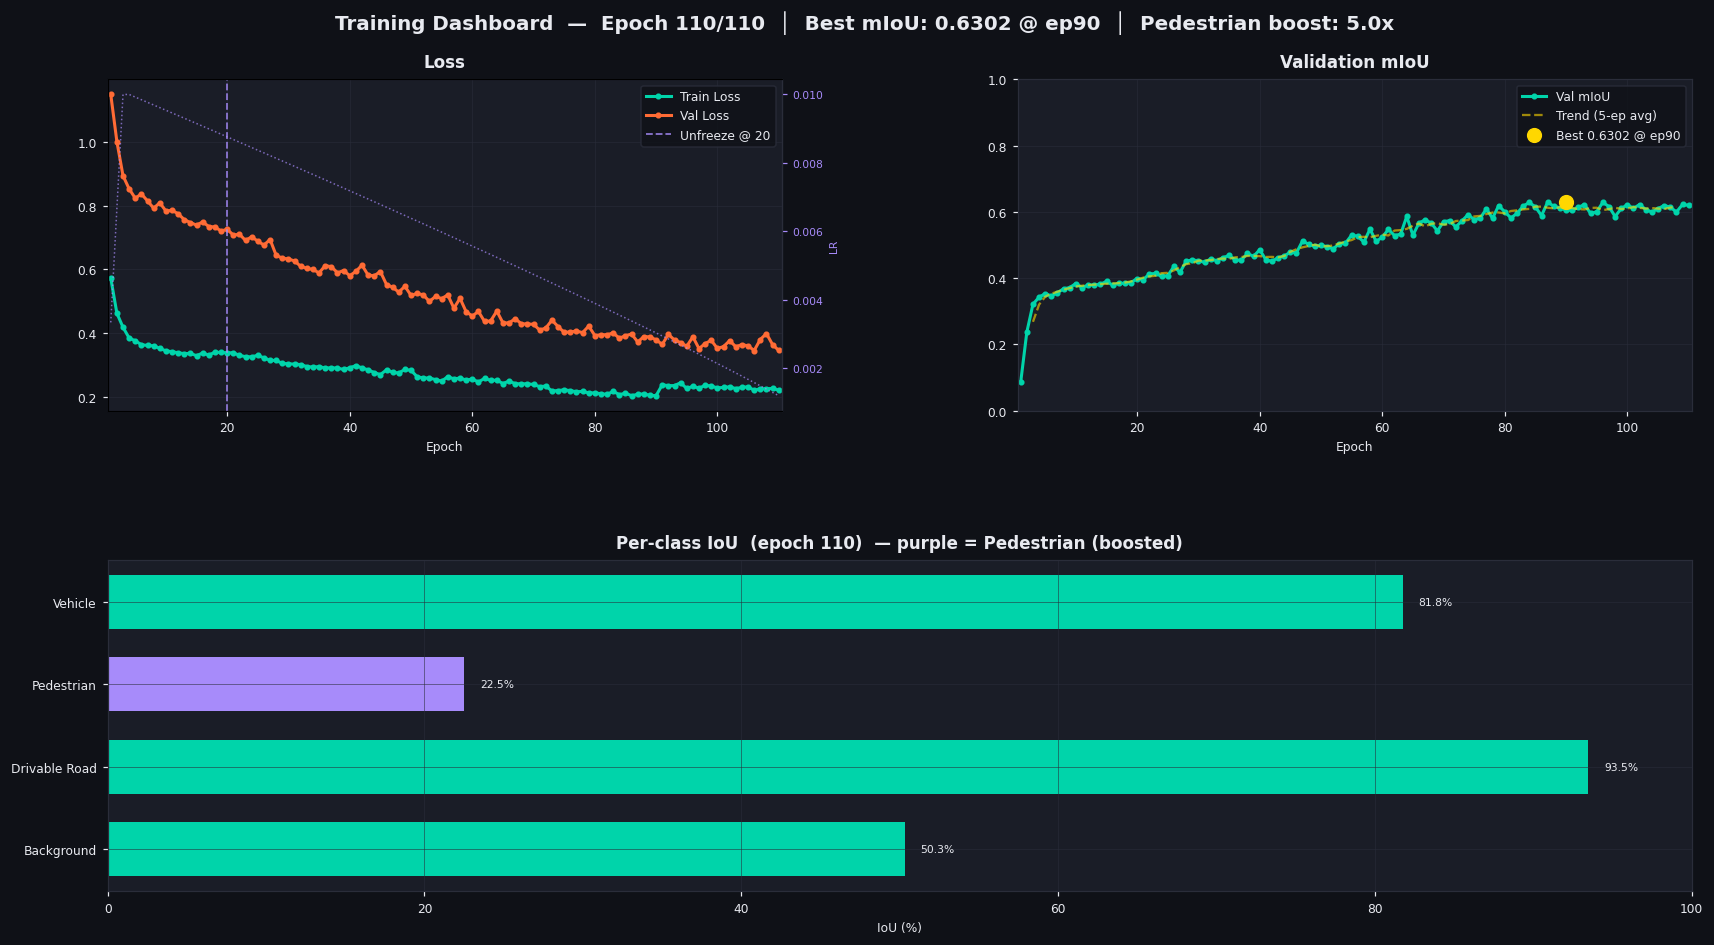

Epoch 110/110  LR:0.001191  Train:0.2211  Val:0.3457  Gap:+0.1246  mIoU:0.6201  PixAcc:0.9132  ⏱453s  ETA:0s  🔓  ✅ healthy
  EarlyStopping: no improvement for 14/20 epochs

══════════════════════════════════════════════════════════════════════
Training complete.
  Best val mIoU : 0.6302  (epoch 90)
  Best model    : /content/bdd100k_phase2/checkpoints/best_model.pth
  Latest ckpt   : /content/bdd100k_phase2/checkpoints/latest_checkpoint.pth
  Final chart   : results/training_curves_live.png
══════════════════════════════════════════════════════════════════════

  ↓ Downloading FINAL best_model.pth (46.1 MB) — check browser downloads…


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ↓ Downloading FINAL latest_checkpoint.pth (46.1 MB) — check browser downloads…


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
import sys, os, time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import GradScaler
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from IPython.display import display, HTML, clear_output
import io, base64

# ─────────────────────────────────────────────────────────────────────────────
# Constants
# ─────────────────────────────────────────────────────────────────────────────
CHART_SAVE_PATH = os.path.join("results", "training_curves_live.png")

# FIX 1 — Fixed total for LR decay so raising EPOCHS doesn't break the schedule.
TOTAL_DECAY_EPOCHS = 120


# ─────────────────────────────────────────────────────────────────────────────
# ✅ DEBIAS 1 — Override config sampling to focus on Pedestrian only.
# Vehicle (class 3) is common enough by now — no need to boost it further.
# Pedestrian (class 2) is ~5% of pixels and is almost certainly your weakest class.
# Raising from 3x → 5x gives it significantly more training signal per epoch.
# ─────────────────────────────────────────────────────────────────────────────
RARE_CLASS_IDS   = [2]      # Pedestrian only (was [2, 3])
OVERSAMPLE_RATIO = 5.0      # 5x more likely to be sampled (was 3.0)


# ─────────────────────────────────────────────────────────────────────────────
# Utility: flush print
# ─────────────────────────────────────────────────────────────────────────────
def fprint(*args, **kwargs):
    print(*args, **kwargs)
    sys.stdout.flush()


# ─────────────────────────────────────────────────────────────────────────────
# Utility: Colab download (silent outside Colab)
# ─────────────────────────────────────────────────────────────────────────────
def _colab_download(path, label=""):
    try:
        from google.colab import files
        if os.path.exists(path):
            size_mb = os.path.getsize(path) / 1e6
            fprint(f"  ↓ Downloading {label} ({size_mb:.1f} MB) — check browser downloads…")
            files.download(path)
        else:
            fprint(f"  ⚠️  {label} not found at {path}, skipping download.")
    except ImportError:
        pass


# ─────────────────────────────────────────────────────────────────────────────
# Atomic checkpoint save (prevents corrupt files on Colab crash)
# ─────────────────────────────────────────────────────────────────────────────
def _safe_save(payload, path):
    os.makedirs(os.path.dirname(path) if os.path.dirname(path) else ".", exist_ok=True)
    tmp = path + ".tmp"
    torch.save(payload, tmp)
    os.replace(tmp, path)


# ─────────────────────────────────────────────────────────────────────────────
# Live chart
# ─────────────────────────────────────────────────────────────────────────────
def _render_live_chart(
    train_losses, val_losses, val_mean_ious,
    best_miou, best_epoch,
    current_epoch, total_epochs,
    per_class_iou=None, class_names=None,
    phase_switch_epoch=None,
    lr_history=None,
):
    if not train_losses:
        fprint("  ⚠️  Chart skipped — no loss data yet.")
        return

    C = dict(
        bg="#0f1117", panel="#1a1d27", text="#e8eaf0",
        teal="#00d4aa", orange="#ff6b35", gold="#ffd700",
        purple="#a78bfa", grid="#2a2d3a",
    )

    fig = plt.figure(figsize=(16, 9), facecolor=C["bg"])
    gs  = gridspec.GridSpec(
        2, 2, figure=fig,
        hspace=0.45, wspace=0.35,
        left=0.07, right=0.97, top=0.90, bottom=0.08,
    )

    ax_loss = fig.add_subplot(gs[0, 0])
    ax_miou = fig.add_subplot(gs[0, 1])
    ax_bar  = fig.add_subplot(gs[1, :])

    n_pts    = len(train_losses)
    ep_range = list(range(1, n_pts + 1))

    for ax in [ax_loss, ax_miou, ax_bar]:
        ax.set_facecolor(C["panel"])
        ax.tick_params(colors=C["text"], labelsize=8)
        for sp in ax.spines.values():
            sp.set_color(C["grid"])
        ax.grid(True, color=C["grid"], linewidth=0.5, alpha=0.7)

    # ── Loss curves ──────────────────────────────────────────────────────────
    ax_loss.plot(ep_range, train_losses, color=C["teal"],   lw=2,
                 marker='o', markersize=3, label="Train Loss")
    ax_loss.plot(ep_range, val_losses,   color=C["orange"], lw=2,
                 marker='o', markersize=3, label="Val Loss")

    if lr_history and len(lr_history) == n_pts:
        ax_lr = ax_loss.twinx()
        ax_lr.plot(ep_range, lr_history, color=C["purple"], lw=1,
                   linestyle=':', alpha=0.7, label="LR")
        ax_lr.set_ylabel("LR", color=C["purple"], fontsize=7)
        ax_lr.tick_params(colors=C["purple"], labelsize=7)
        ax_lr.spines['right'].set_color(C["grid"])

    if phase_switch_epoch and phase_switch_epoch <= n_pts:
        ax_loss.axvline(
            phase_switch_epoch, color=C["purple"], lw=1.2,
            linestyle="--", alpha=0.8, label=f"Unfreeze @ {phase_switch_epoch}",
        )

    ax_loss.set_title("Loss", color=C["text"], fontsize=11, fontweight="bold", pad=8)
    ax_loss.set_xlabel("Epoch", color=C["text"], fontsize=8)
    ax_loss.set_xlim(0.5, max(total_epochs, n_pts) + 0.5)
    ax_loss.legend(fontsize=8, facecolor=C["bg"], edgecolor=C["grid"],
                   labelcolor=C["text"])

    # ── mIoU curve ───────────────────────────────────────────────────────────
    ax_miou.plot(ep_range, val_mean_ious, color=C["teal"], lw=2,
                 marker='o', markersize=3, label="Val mIoU")

    if n_pts >= 5:
        kernel   = np.ones(5) / 5
        smoothed = np.convolve(val_mean_ious, kernel, mode='valid')
        smooth_x = list(range(3, n_pts - 1))
        ax_miou.plot(smooth_x, smoothed, color=C["gold"], lw=1.5,
                     linestyle='--', alpha=0.6, label="Trend (5-ep avg)")

    if best_epoch and best_epoch <= n_pts:
        ax_miou.scatter(
            [best_epoch], [best_miou],
            color=C["gold"], zorder=5, s=80,
            label=f"Best {best_miou:.4f} @ ep{best_epoch}",
        )

    ax_miou.set_title("Validation mIoU", color=C["text"], fontsize=11,
                      fontweight="bold", pad=8)
    ax_miou.set_xlabel("Epoch", color=C["text"], fontsize=8)
    ax_miou.set_ylim(0, 1)
    ax_miou.set_xlim(0.5, max(total_epochs, n_pts) + 0.5)
    ax_miou.legend(fontsize=8, facecolor=C["bg"], edgecolor=C["grid"],
                   labelcolor=C["text"])

    # ── Per-class IoU bar chart ───────────────────────────────────────────────
    if per_class_iou is not None and class_names is not None:
        n      = len(class_names)
        vals   = [float(v) * 100 for v in per_class_iou]
        # ✅ DEBIAS visual — highlight pedestrian bar differently so you can
        # track its improvement epoch by epoch at a glance
        colors = []
        for idx, v in enumerate(vals):
            if idx == 2:   # Pedestrian
                colors.append(C["purple"] if v < 50 else C["teal"])
            else:
                colors.append(C["teal"] if v >= 50 else C["orange"])
        bars = ax_bar.barh(range(n), vals, color=colors, height=0.65)
        ax_bar.set_yticks(range(n))
        ax_bar.set_yticklabels(class_names, fontsize=8, color=C["text"])
        ax_bar.set_xlim(0, 100)
        ax_bar.set_xlabel("IoU (%)", color=C["text"], fontsize=8)
        ax_bar.set_title(
            f"Per-class IoU  (epoch {current_epoch})  "
            f"— purple = Pedestrian (boosted)",
            color=C["text"], fontsize=11, fontweight="bold", pad=8,
        )
        for bar, v in zip(bars, vals):
            ax_bar.text(
                min(v + 1, 96), bar.get_y() + bar.get_height() / 2,
                f"{v:.1f}%", va="center", fontsize=7, color=C["text"],
            )
    else:
        ax_bar.text(
            0.5, 0.5, "Per-class IoU will appear after first epoch",
            ha="center", va="center", transform=ax_bar.transAxes,
            color=C["text"], fontsize=10,
        )
        ax_bar.set_title("Per-class IoU", color=C["text"], fontsize=11,
                         fontweight="bold", pad=8)

    fig.suptitle(
        f"Training Dashboard  —  Epoch {current_epoch}/{total_epochs}  │  "
        f"Best mIoU: {best_miou:.4f} @ ep{best_epoch}  │  "
        f"Pedestrian boost: {OVERSAMPLE_RATIO}x",
        color=C["text"], fontsize=13, fontweight="bold", y=0.97,
    )

    os.makedirs("results", exist_ok=True)
    tmp_chart = CHART_SAVE_PATH + ".tmp"
    fig.savefig(tmp_chart, format="png", dpi=110,
                bbox_inches="tight", facecolor=C["bg"])
    os.replace(tmp_chart, CHART_SAVE_PATH)
    fprint(f"  📊 Chart saved → {CHART_SAVE_PATH}")

    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=110, bbox_inches="tight", facecolor=C["bg"])
    plt.close(fig)
    buf.seek(0)
    b64  = base64.b64encode(buf.read()).decode()
    html = f'<img src="data:image/png;base64,{b64}" style="max-width:100%;"/>'

    clear_output(wait=True)
    display(HTML(html))
    sys.stdout.flush()


# ─────────────────────────────────────────────────────────────────────────────
# LR schedule — anchored to TOTAL_DECAY_EPOCHS
# ─────────────────────────────────────────────────────────────────────────────
def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    prog = (epoch - WARMUP_EPOCHS) / max(TOTAL_DECAY_EPOCHS - WARMUP_EPOCHS, 1)
    prog = min(prog, 1.0)
    return max((1 - prog) ** 0.9, 1e-4)


# ─────────────────────────────────────────────────────────────────────────────
# Model / optimizer / scheduler / scaler
# ─────────────────────────────────────────────────────────────────────────────
model, model_name = create_ddrnet_model(NUM_CLASSES, use_pretrained=USE_PRETRAINED_BACKBONE)
model.to(device)

# ── Base class weights from scan ──────────────────────────────────────────────
if not isinstance(class_weights, torch.Tensor) or len(class_weights) != NUM_CLASSES:
    class_weights = torch.ones(NUM_CLASSES, dtype=torch.float32)
class_weights = class_weights[:NUM_CLASSES].clone()

# ✅ DEBIAS 2 — Manually boost pedestrian loss weight AFTER the scan-computed
# weights. The scan already inverse-frequencies the classes, but pedestrian is
# so rare that it still gets undertrained. A 1.5x multiplier on top pushes the
# loss to penalise pedestrian mistakes harder without destabilising other classes.
# Background (0) and Road (1) are dominant — slightly reduce their influence
# so the gradient budget isn't monopolised by easy pixels.
PEDESTRIAN_WEIGHT_BOOST = 1.5   # multiply pedestrian weight by this
BACKGROUND_WEIGHT_SCALE = 0.8   # reduce background weight slightly
ROAD_WEIGHT_SCALE       = 0.9   # reduce road weight slightly

class_weights[0] *= BACKGROUND_WEIGHT_SCALE   # Background
class_weights[1] *= ROAD_WEIGHT_SCALE          # Drivable Road
class_weights[2] *= PEDESTRIAN_WEIGHT_BOOST    # Pedestrian  ← boosted
# class_weights[3] unchanged                   # Vehicle — leave as-is

# Renormalise so the total weight stays at NUM_CLASSES (keeps loss scale stable)
class_weights = class_weights / class_weights.mean()
class_weights = class_weights.to(device)

fprint("  Class weights after debias adjustment:")
for i, (nm, w) in enumerate(zip(OUR_CLASS_NAMES, class_weights.tolist())):
    marker = "  ← boosted" if i == 2 else ("  ← reduced" if i in [0, 1] else "")
    fprint(f"    [{i}] {nm:<18}: {w:.4f}{marker}")

if USE_DICE_LOSS:
    criterion = CombinedLoss(NUM_CLASSES, class_weights, IGNORE_INDEX, DICE_WEIGHT)
else:
    criterion = nn.CrossEntropyLoss(weight=class_weights, ignore_index=IGNORE_INDEX)

optimizer      = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=0.9,
                           weight_decay=WEIGHT_DECAY, nesterov=True)
scheduler      = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)
scaler         = GradScaler(enabled=True)
early_stopping = EarlyStopping(patience=EARLY_STOP_PATIENCE)

# ── Auto-resume ───────────────────────────────────────────────────────────────
start_epoch, best_miou, train_losses, val_losses, val_mean_ious = \
    load_checkpoint_if_exists(model, optimizer, scheduler, scaler)

# Restore LR history from checkpoint if available, else reconstruct
if hasattr(train_losses, '__len__') and len(train_losses) > 0:
    lr_history = [LEARNING_RATE * lr_lambda(e) for e in range(len(train_losses))]
else:
    lr_history = []

if start_epoch >= EPOCHS:
    fprint(f'\n⚠️  start_epoch ({start_epoch}) >= EPOCHS ({EPOCHS}).')
    fprint(f'   Raise EPOCHS in the config cell (currently {EPOCHS}) and re-run.')

# ── Phase 1: freeze backbone if enabled ───────────────────────────────────────
_backbone_frozen   = False
_phase_switch_done = False
_phase_switch_at   = None

if USE_PRETRAINED_BACKBONE and FREEZE_BACKBONE_EPOCHS > 0:
    if start_epoch < FREEZE_BACKBONE_EPOCHS:
        model.freeze_backbone()
        _backbone_frozen = True
        fprint(f'  Phase 1 — backbone frozen until epoch {FREEZE_BACKBONE_EPOCHS}')
    else:
        model.unfreeze_backbone()
        _phase_switch_done = True
        _phase_switch_at   = FREEZE_BACKBONE_EPOCHS
        fprint(f'  Resuming in Phase 2 — backbone already unfrozen')

fprint(f'\nStarting training from epoch {start_epoch + 1}/{EPOCHS}')
fprint(f'Model           : {model_name}')
fprint(f'Pretrained      : {USE_PRETRAINED_BACKBONE}  '
       f'(freeze {FREEZE_BACKBONE_EPOCHS} epochs then unfreeze)')
fprint(f'TTA             : {USE_TTA}')
fprint(f'Loss            : {"CombinedLoss (CE+Dice)" if USE_DICE_LOSS else "CrossEntropy"}')
fprint(f'AMP             : {scaler.is_enabled()}')
fprint(f'Grad clip norm  : {GRAD_CLIP_NORM}')
fprint(f'Early stopping  : patience={EARLY_STOP_PATIENCE}')
fprint(f'Train samples   : {TRAIN_SAMPLES_PER_EPOCH:,}/epoch '
       f'(pool {len(train_dataset):,})')
fprint(f'Val samples     : {VAL_SAMPLES_PER_EPOCH:,}/epoch  '
       f'(pool {len(val_dataset):,})')
fprint(f'Pedestrian boost: oversample={OVERSAMPLE_RATIO}x  '
       f'weight_boost={PEDESTRIAN_WEIGHT_BOOST}x')
fprint(f'Auto-download   : {AUTO_DOWNLOAD_BEST_MODEL}')
fprint(f'LR decay anchor : {TOTAL_DECAY_EPOCHS} epochs  '
       f'(current LR at ep{start_epoch}: '
       f'{LEARNING_RATE * lr_lambda(max(start_epoch-1, 0)):.6f})')
fprint()

epoch_times      = []
# ✅ DEBIAS 1 — use updated RARE_CLASS_IDS and OVERSAMPLE_RATIO defined at top
_weights_arg     = train_sample_weights if USE_CLASS_AWARE_SAMPLING else None
_last_best_epoch = start_epoch if start_epoch > 0 else 1
_last_per_class  = None


# ─────────────────────────────────────────────────────────────────────────────
# MAIN TRAINING LOOP
# ─────────────────────────────────────────────────────────────────────────────
for epoch in range(start_epoch, EPOCHS):
    t0         = time.time()
    current_lr = optimizer.param_groups[0]['lr']

    # ── Phase 2: unfreeze backbone ────────────────────────────────────────────
    if (USE_PRETRAINED_BACKBONE and FREEZE_BACKBONE_EPOCHS > 0
            and _backbone_frozen and epoch >= FREEZE_BACKBONE_EPOCHS
            and not _phase_switch_done):
        fprint(f'\n🔓 Epoch {epoch+1}: Phase 2 — unfreezing backbone for full fine-tune')
        model.unfreeze_backbone()
        _backbone_frozen   = False
        _phase_switch_done = True
        _phase_switch_at   = epoch + 1
        for pg in optimizer.param_groups:
            pg['lr'] = LEARNING_RATE * UNFREEZE_LR_SCALE
        fprint(f'   LR → {LEARNING_RATE * UNFREEZE_LR_SCALE:.5f}')

    # ── Fresh data loaders each epoch ─────────────────────────────────────────
    train_loader, val_loader = make_epoch_dataloaders(
        train_dataset, val_dataset,
        TRAIN_SAMPLES_PER_EPOCH, VAL_SAMPLES_PER_EPOCH,
        BATCH_SIZE, NUM_WORKERS,
        train_weights=_weights_arg,
    )

    # ── Train ─────────────────────────────────────────────────────────────────
    fprint(f'\n{"═"*70}')
    fprint(f'  Epoch {epoch+1}/{EPOCHS}  |  LR: {current_lr:.6f}  |  '
           f'Phase: {"🔒 frozen" if _backbone_frozen else "🔓 unfrozen"}')
    fprint(f'{"═"*70}')
    fprint('  ▶ Training …')
    sys.stdout.flush()

    train_loss = train_one_epoch(
        model, train_loader, optimizer, criterion,
        device, scaler, scheduler, GRAD_CLIP_NORM,
    )
    fprint(f'  ✔ Train loss : {train_loss:.4f}')

    # ── Validate ──────────────────────────────────────────────────────────────
    fprint('  ▶ Validating …')
    sys.stdout.flush()

    val_loss, val_metrics = validate(
        model, val_loader, criterion, device, NUM_CLASSES, IGNORE_INDEX, scaler,
        use_tta=USE_TTA, tta_scales=TTA_SCALES,
    )
    fprint(f'  ✔ Val loss   : {val_loss:.4f}')
    fprint(f'  ✔ Val mIoU   : {val_metrics["mean_iou"]:.4f}')
    fprint(f'  ✔ Pixel acc  : {val_metrics["pixel_accuracy"]:.4f}')

    # ── Timing ────────────────────────────────────────────────────────────────
    epoch_time = time.time() - t0
    epoch_times.append(epoch_time)
    avg_time  = sum(epoch_times) / len(epoch_times)
    remaining = avg_time * (EPOCHS - epoch - 1)
    eta_str   = (f'{int(remaining//3600)}h{int((remaining%3600)//60)}m'
                 if remaining > 60 else f'{int(remaining)}s')

    val_mean_iou = val_metrics['mean_iou']

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_mean_ious.append(val_mean_iou)
    lr_history.append(current_lr)

    # ── Best model check ──────────────────────────────────────────────────────
    is_best = val_mean_iou > best_miou
    if is_best:
        best_miou        = val_mean_iou
        _last_best_epoch = epoch + 1

    # ── Fit status ────────────────────────────────────────────────────────────
    loss_gap = val_loss - train_loss
    if loss_gap > 0.25:
        fit_status = '⚠️  OVERFIT'
    elif train_loss > 1.0 and val_loss > 1.0:
        fit_status = '⚠️  UNDERFIT'
    else:
        fit_status = '✅ healthy'

    fprint(f'\n  {"★ NEW BEST! " if is_best else ""}Gap:{loss_gap:+.4f}  '
           f'ETA:{eta_str}  ⏱{epoch_time:.0f}s  {fit_status}')

    # ── Per-class IoU — highlight pedestrian progress ─────────────────────────
    _last_per_class = val_metrics['per_class_iou']
    fprint('\n  Per-class IoU:')
    for i, nm in enumerate(OUR_CLASS_NAMES):
        iou    = _last_per_class[i] * 100
        bar    = '█' * int(iou / 2) + '░' * (50 - int(iou / 2))
        # ✅ DEBIAS — flag pedestrian row so you can track its improvement
        tag    = '  ← PEDESTRIAN (boosted)' if i == 2 else ''
        fprint(f'    {nm:<18}: {iou:5.2f}%  {bar[:30]}{tag}')

    # ── Save checkpoints (atomic) ─────────────────────────────────────────────
    ckpt_payload = {
        'epoch'               : epoch + 1,
        'model_state_dict'    : model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'scaler_state_dict'   : scaler.state_dict(),
        'best_miou'           : best_miou,
        'train_losses'        : train_losses,
        'val_losses'          : val_losses,
        'val_mean_ious'       : val_mean_ious,
        'lr_history'          : lr_history,
        'model_name'          : model_name,
        'num_classes'         : NUM_CLASSES,
        'img_height'          : IMG_HEIGHT,
        'img_width'           : IMG_WIDTH,
    }

    _safe_save(ckpt_payload, LATEST_CKPT_PATH)
    fprint(f'\n  💾 latest checkpoint saved → {LATEST_CKPT_PATH}')

    if is_best:
        _safe_save(ckpt_payload, BEST_CKPT_PATH)
        fprint(f'  💾 best model saved     → {BEST_CKPT_PATH}  '
               f'(mIoU={best_miou:.4f})')

    _colab_download(LATEST_CKPT_PATH, label=f"latest_checkpoint (ep{epoch+1})")
    if is_best and AUTO_DOWNLOAD_BEST_MODEL:
        _colab_download(BEST_CKPT_PATH,
                        label=f"best_model (ep{epoch+1}, mIoU={best_miou:.4f})")

    try:
        _render_live_chart(
            train_losses       = train_losses,
            val_losses         = val_losses,
            val_mean_ious      = val_mean_ious,
            best_miou          = best_miou,
            best_epoch         = _last_best_epoch,
            current_epoch      = epoch + 1,
            total_epochs       = EPOCHS,
            per_class_iou      = _last_per_class,
            class_names        = OUR_CLASS_NAMES,
            phase_switch_epoch = _phase_switch_at,
            lr_history         = lr_history,
        )
    except Exception as e:
        fprint(f'  ⚠️  Chart update failed: {e}')

    fprint(
        f'Epoch {epoch+1:3d}/{EPOCHS}  '
        f'LR:{current_lr:.6f}  '
        f'Train:{train_loss:.4f}  '
        f'Val:{val_loss:.4f}  '
        f'Gap:{loss_gap:+.4f}  '
        f'mIoU:{val_mean_iou:.4f}  '
        f'PixAcc:{val_metrics["pixel_accuracy"]:.4f}  '
        f'⏱{epoch_time:.0f}s  ETA:{eta_str}  '
        f'{"🔒" if _backbone_frozen else "🔓"}  '
        f'{fit_status}'
        + ('  ★ BEST' if is_best else '')
    )

    # ── Early stopping — only after warmup ───────────────────────────────────
    if epoch >= 20 and early_stopping.step(val_mean_iou):
        fprint(f'\n⏹ Early stopping triggered at epoch {epoch+1}.')
        break


# ─────────────────────────────────────────────────────────────────────────────
# End-of-training summary
# ─────────────────────────────────────────────────────────────────────────────
fprint(f'\n{"═"*70}')
fprint(f'Training complete.')
fprint(f'  Best val mIoU : {best_miou:.4f}  (epoch {_last_best_epoch})')
fprint(f'  Best model    : {BEST_CKPT_PATH}')
fprint(f'  Latest ckpt   : {LATEST_CKPT_PATH}')
fprint(f'  Final chart   : {CHART_SAVE_PATH}')
fprint(f'{"═"*70}\n')

if AUTO_DOWNLOAD_BEST_MODEL:
    _colab_download(BEST_CKPT_PATH,   label="FINAL best_model.pth")
    _colab_download(LATEST_CKPT_PATH, label="FINAL latest_checkpoint.pth")
else:
    fprint('Auto-download disabled. To manually download:')
    fprint('  from google.colab import files')
    fprint(f'  files.download("{BEST_CKPT_PATH}")')
    fprint(f'  files.download("{LATEST_CKPT_PATH}")')

In [22]:
# ── LOAD CHECKPOINT + PRINT HISTORY ─────────────────────────────

import torch
import os

def show_training_history(ckpt_path):
    if not os.path.exists(ckpt_path):
        print(f"❌ Checkpoint not found at: {ckpt_path}")
        return

    ckpt = torch.load(ckpt_path, map_location="cpu")

    train_losses   = ckpt.get("train_losses", [])
    val_losses     = ckpt.get("val_losses", [])
    val_mean_ious  = ckpt.get("val_mean_ious", [])
    best_miou      = ckpt.get("best_miou", None)
    last_epoch     = ckpt.get("epoch", None)

    print("\n📜 TRAINING HISTORY")
    print("=" * 70)

    if len(train_losses) == 0:
        print("⚠️ No history found in checkpoint.")
        return

    for i in range(len(train_losses)):
        print(
            f"Epoch {i+1:3d} | "
            f"Train Loss: {train_losses[i]:.4f} | "
            f"Val Loss: {val_losses[i]:.4f} | "
            f"mIoU: {val_mean_ious[i]:.4f}"
        )

    print("=" * 70)
    print(f"📌 Last Epoch   : {last_epoch}")
    print(f"🏆 Best mIoU   : {best_miou:.4f}" if best_miou is not None else "")
    print("=" * 70)


# ── CALL (you can use either latest or best) ─────────────────────

print("\n🔹 FROM LATEST CHECKPOINT")
show_training_history(LATEST_CKPT_PATH)

# Optional:
# print("\n🔹 FROM BEST MODEL CHECKPOINT")
# show_training_history(BEST_CKPT_PATH)


🔹 FROM LATEST CHECKPOINT

📜 TRAINING HISTORY
Epoch   1 | Train Loss: 0.5726 | Val Loss: 1.1490 | mIoU: 0.0868
Epoch   2 | Train Loss: 0.4622 | Val Loss: 1.0011 | mIoU: 0.2376
Epoch   3 | Train Loss: 0.4183 | Val Loss: 0.8939 | mIoU: 0.3214
Epoch   4 | Train Loss: 0.3845 | Val Loss: 0.8526 | mIoU: 0.3429
Epoch   5 | Train Loss: 0.3759 | Val Loss: 0.8234 | mIoU: 0.3534
Epoch   6 | Train Loss: 0.3637 | Val Loss: 0.8368 | mIoU: 0.3467
Epoch   7 | Train Loss: 0.3612 | Val Loss: 0.8150 | mIoU: 0.3563
Epoch   8 | Train Loss: 0.3601 | Val Loss: 0.7920 | mIoU: 0.3680
Epoch   9 | Train Loss: 0.3521 | Val Loss: 0.8089 | mIoU: 0.3717
Epoch  10 | Train Loss: 0.3442 | Val Loss: 0.7833 | mIoU: 0.3838
Epoch  11 | Train Loss: 0.3419 | Val Loss: 0.7853 | mIoU: 0.3718
Epoch  12 | Train Loss: 0.3381 | Val Loss: 0.7746 | mIoU: 0.3793
Epoch  13 | Train Loss: 0.3357 | Val Loss: 0.7561 | mIoU: 0.3796
Epoch  14 | Train Loss: 0.3360 | Val Loss: 0.7468 | mIoU: 0.3819
Epoch  15 | Train Loss: 0.3292 | Val Loss: 0

In [23]:
# ─────────────────────────────────────────────
# DOWNLOAD CHECKPOINTS (Colab only)
# ─────────────────────────────────────────────

from google.colab import files
import os

if os.path.exists(LATEST_CKPT_PATH):
    print(f"⬇️ Downloading latest checkpoint: {LATEST_CKPT_PATH}")
    files.download(LATEST_CKPT_PATH)
else:
    print(f"⚠️ Latest checkpoint not found: {LATEST_CKPT_PATH}")

if os.path.exists(BEST_CKPT_PATH):
    print(f"⬇️ Downloading best model: {BEST_CKPT_PATH}")
    files.download(BEST_CKPT_PATH)
else:
    print(f"⚠️ Best model not found: {BEST_CKPT_PATH}")

⬇️ Downloading latest checkpoint: /content/bdd100k_phase2/checkpoints/latest_checkpoint.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️ Downloading best model: /content/bdd100k_phase2/checkpoints/best_model.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Section 16 — Training Curves + Overfitting/Underfitting Analysis

In [ ]:
epochs_x = list(range(1, len(train_losses) + 1))
fig, axes = plt.subplots(1, 3, figsize=(22, 5))

# ── Loss curves ───────────────────────────────────────────────────────────────
axes[0].plot(epochs_x, train_losses, 'b-o', markersize=3, linewidth=2, label='Train Loss')
axes[0].plot(epochs_x, val_losses,   'r-o', markersize=3, linewidth=2, label='Val Loss')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(bottom=0)

# ── mIoU curve ────────────────────────────────────────────────────────────────
axes[1].plot(epochs_x, val_mean_ious, 'g-o', markersize=3, linewidth=2, label='Val mIoU')
if best_miou > 0:
    axes[1].axhline(y=best_miou, color='darkgreen', linestyle='--', alpha=0.7,
                    label=f'Best: {best_miou:.4f}')
axes[1].set_title('Validation mIoU over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('mIoU')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(bottom=0)

# ── Train/Val gap (overfitting detector) ──────────────────────────────────────
gap = [v - t for t, v in zip(train_losses, val_losses)]
axes[2].plot(epochs_x, gap, 'm-o', markersize=3, linewidth=2, label='Val - Train Loss')
axes[2].axhline(y=0,   color='black', linestyle='--', alpha=0.5, label='Zero gap')
axes[2].axhline(y=0.3, color='red',   linestyle='--', alpha=0.5, label='Overfit threshold (0.3)')
axes[2].fill_between(epochs_x, gap, 0,
                     where=[g > 0.3 for g in gap],
                     color='red', alpha=0.15, label='Overfitting zone')
axes[2].fill_between(epochs_x, gap, 0,
                     where=[g <= 0 for g in gap],
                     color='blue', alpha=0.1, label='Val < Train (normal w/ augment)')
axes[2].set_title('Overfitting/Underfitting Gap\n(Val Loss − Train Loss)')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss Gap')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.suptitle(
    f'Phase 2 Training — {model_name} | Best mIoU: {best_miou:.4f} | {len(epochs_x)} epochs',
    fontsize=14
)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'training_curves_phase2.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Text summary ──────────────────────────────────────────────────────────────
if train_losses:
    final_gap = val_losses[-1] - train_losses[-1]
    print(f'Final train loss : {train_losses[-1]:.4f}')
    print(f'Final val loss   : {val_losses[-1]:.4f}')
    print(f'Final gap        : {final_gap:+.4f}')
    print(f'Best val mIoU    : {best_miou:.4f}')
    print()
    if final_gap > 0.3:
        print('📊 Diagnosis: OVERFITTING')
        print('   → Val loss is much higher than train loss')
        print('   → Try: more dropout, stronger augmentation, fewer epochs, smaller model')
    elif train_losses[-1] > 1.0 and val_losses[-1] > 1.0:
        print('📊 Diagnosis: UNDERFITTING')
        print('   → Both losses are still high')
        print('   → Try: more epochs, higher LR, larger model, less regularisation')
    else:
        print('📊 Diagnosis: HEALTHY — model is generalising well ✅')
else:
    print('No epochs completed yet — run the training cell first.')

Final train loss : 0.2038
Final val loss   : 0.3787
Final gap        : +0.1749
Best val mIoU    : 0.6302

📊 Diagnosis: HEALTHY — model is generalising well ✅


## Section 17 — Load Best Model + Full Evaluation

In [ ]:
best_miou_loaded = load_best_model(model)
print('\nRunning full validation pass on best model...')

# Use a large val sample for final evaluation
_final_tl, val_loader_full = make_epoch_dataloaders(
    train_dataset, val_dataset,
    TRAIN_SAMPLES_PER_EPOCH, min(5000, len(val_dataset)),
    BATCH_SIZE, NUM_WORKERS
)
del _final_tl

val_loss_f, val_metrics_f = validate(
    model, val_loader_full, criterion, device, NUM_CLASSES, IGNORE_INDEX, scaler
)

print()
print('=' * 55)
print('EVALUATION RESULTS (Best Checkpoint)')
print('=' * 55)
print(f'  Model          : {model_name}')
print(f'  Val Loss       : {val_loss_f:.4f}')
print(f'  mIoU           : {val_metrics_f["mean_iou"]*100:.2f}%')
print(f'  Pixel Accuracy : {val_metrics_f["pixel_accuracy"]*100:.2f}%')
print()
print('  Per-class IoU:')
for i, nm in enumerate(OUR_CLASS_NAMES):
    iou = val_metrics_f['per_class_iou'][i] * 100
    print(f'    {nm:<15}: {iou:.2f}%')

Best model loaded — epoch 87  mIoU: 0.6302

Running full validation pass on best model...


Validation:   0%|          | 0/313 [00:00<?, ?it/s]


EVALUATION RESULTS (Best Checkpoint)
  Model          : DDRNet-23-slim
  Val Loss       : 0.3933
  mIoU           : 60.62%
  Pixel Accuracy : 91.61%

  Per-class IoU:
    Background     : 38.40%
    Drivable Road  : 92.70%
    Pedestrian     : 28.97%
    Vehicle        : 82.39%


## Section 15b — 30+ FPS Proof (Engineering Trick #3)
100-frame timed inference, CUDA synchronised.

In [ ]:
print('=' * 60)
print('FPS BENCHMARK — DDRNet-23-slim at 512×1024')
print('=' * 60)

model.eval()
dummy_input = torch.randn(1, 3, IMG_HEIGHT, IMG_WIDTH).to(device)

with torch.no_grad():
    for _ in range(5):
        _ = model(dummy_input)
torch.cuda.synchronize()

N_FRAMES = 100
torch.cuda.synchronize()
t_start = time.time()
with torch.no_grad():
    for _ in range(N_FRAMES):
        _ = model(dummy_input)
torch.cuda.synchronize()
t_end = time.time()

elapsed = t_end - t_start
fps     = N_FRAMES / elapsed
ms_per  = elapsed / N_FRAMES * 1000

print(f'Frames tested  : {N_FRAMES}')
print(f'Total time     : {elapsed:.2f}s')
print(f'Latency        : {ms_per:.1f} ms/frame')
print(f'FPS            : {fps:.1f}')

if fps >= 30:
    print(f'\nFPS: {fps:.1f} ✅  (target: ≥30 FPS — ACHIEVED)')
else:
    print(f'\nFPS: {fps:.1f} ⚠️  (target: ≥30 FPS — not yet achieved; check GPU assignment)')

del dummy_input
torch.cuda.empty_cache()
model.train()

FPS BENCHMARK — DDRNet-23-slim at 512×1024
Frames tested  : 100
Total time     : 0.78s
Latency        : 7.8 ms/frame
FPS            : 127.8

FPS: 127.8 ✅  (target: ≥30 FPS — ACHIEVED)


DDRNetWrapper(
  (bb): DualResNet(
    (conv1): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
    (relu): ReLU()
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(3

## Section 19 — Qualitative Predictions Visualisation

In [ ]:
if 'val_metrics_f' not in dir():
    print('⚠️  val_metrics_f not found — run Section 17 first.')
    val_metrics_f = {'mean_iou': float('nan'), 'per_class_iou': [0.0] * NUM_CLASSES}

val_imgs = sorted(glob.glob(os.path.join(VAL_IMG_DIR,  '*.jpg')))
val_msks = sorted(glob.glob(os.path.join(VAL_MASK_DIR, '*.png')))
msk_dict = {os.path.splitext(os.path.basename(p))[0]: p for p in val_msks}

paired   = [
    (p, msk_dict[os.path.splitext(os.path.basename(p))[0]])
    for p in val_imgs
    if os.path.splitext(os.path.basename(p))[0] in msk_dict
]
vis_pairs = random.sample(paired, min(4, len(paired)))
n_show    = len(vis_pairs)

mean_t = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std_t  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

fig, axes = plt.subplots(n_show, 4, figsize=(26, 5*n_show))
if n_show == 1:
    axes = axes[np.newaxis, :]

model.eval()
with torch.no_grad():
    for i, (img_p, msk_p) in enumerate(vis_pairs):
        img_np  = np.array(Image.open(img_p))
        msk_np  = remap_mask(np.array(Image.open(msk_p)))
        aug     = val_transforms(image=img_np, mask=msk_np)
        img_t   = aug['image'].unsqueeze(0).to(device)
        pred    = model(img_t).argmax(dim=1).squeeze().cpu().numpy()
        img_vis = np.clip((aug['image'] * std_t + mean_t).permute(1,2,0).numpy(), 0, 1)
        gt_col  = colorise_mask(
            cv2.resize(msk_np, (IMG_WIDTH, IMG_HEIGHT), interpolation=cv2.INTER_NEAREST),
            OUR_CLASS_COLOURS
        )
        pd_col  = colorise_mask(pred.astype(np.uint8), OUR_CLASS_COLOURS)
        overlay = cv2.addWeighted((img_vis*255).astype(np.uint8), 0.5, pd_col, 0.5, 0)

        axes[i,0].imshow(img_vis);  axes[i,0].set_title('Input');        axes[i,0].axis('off')
        axes[i,1].imshow(gt_col);   axes[i,1].set_title('Ground Truth'); axes[i,1].axis('off')
        axes[i,2].imshow(pd_col);   axes[i,2].set_title('Prediction');   axes[i,2].axis('off')
        axes[i,3].imshow(overlay);  axes[i,3].set_title('Overlay');      axes[i,3].axis('off')

patches = [mpatches.Patch(color=c/255, label=n) for c, n in zip(OUR_CLASS_COLOURS, OUR_CLASS_NAMES)]
fig.legend(handles=patches, loc='lower center', ncol=4, fontsize=13)
plt.suptitle(
    f'Phase 2 Predictions — {model_name} | mIoU: {val_metrics_f["mean_iou"]*100:.2f}%',
    fontsize=14
)
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.savefig(os.path.join(RESULTS_DIR, 'predictions_phase2.png'), dpi=150, bbox_inches='tight')
plt.show()

## Section 20 — Confusion Matrix + Per-Class IoU Table

In [ ]:
print('Building confusion matrix over validation set...')
model.eval()
all_preds, all_labels = [], []

_cm_tl, _cm_vl = make_epoch_dataloaders(
    train_dataset, val_dataset,
    TRAIN_SAMPLES_PER_EPOCH, min(3000, len(val_dataset)),
    BATCH_SIZE, NUM_WORKERS
)
del _cm_tl

with torch.no_grad():
    for imgs, msks in tqdm(_cm_vl, desc='Confusion matrix'):
        preds = model(imgs.to(device)).argmax(dim=1).cpu().numpy()
        msks  = msks.numpy()
        valid = msks != 255
        all_preds.append(preds[valid].flatten())
        all_labels.append(msks[valid].flatten())

all_preds  = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

cm      = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)
np.add.at(cm, (all_labels.clip(0, NUM_CLASSES-1), all_preds.clip(0, NUM_CLASSES-1)), 1)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues',
            xticklabels=OUR_CLASS_NAMES, yticklabels=OUR_CLASS_NAMES, ax=axes[0])
axes[0].set_title('Confusion Matrix (Pixel Counts)')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

sns.heatmap(cm_norm * 100, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=OUR_CLASS_NAMES, yticklabels=OUR_CLASS_NAMES, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalised %)')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.suptitle(f'Phase 2 Confusion Matrix — {model_name}', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrix_phase2.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\nPer-class IoU Table:')
print(f'{"Class":<15}  {"IoU (%)":>8}  {"TP":>12}  {"FP":>12}  {"FN":>12}')
print('-' * 65)
for i, nm in enumerate(OUR_CLASS_NAMES):
    tp = cm[i, i]
    fp = cm[:, i].sum() - tp
    fn = cm[i, :].sum() - tp
    iou = tp / (tp + fp + fn + 1e-6) * 100
    print(f'{nm:<15}  {iou:>8.2f}%  {tp:>12,}  {fp:>12,}  {fn:>12,}')

print('\nTop confusion pairs:')
tmp = cm_norm.copy()
np.fill_diagonal(tmp, 0)
for _ in range(3):
    r, c = np.unravel_index(tmp.argmax(), tmp.shape)
    print(f'  {OUR_CLASS_NAMES[r]:15} → {OUR_CLASS_NAMES[c]:15}: {tmp[r,c]*100:.1f}%')
    tmp[r, c] = 0

Building confusion matrix over validation set...


Confusion matrix:   0%|          | 0/188 [00:00<?, ?it/s]

Exception in thread Thread-43 (_pin_memory_loop):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py", line 52, in _pin_memory_loop
    do_one_step()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py", line 28, in do_one_step
    r = in_queue.get(timeout=MP_STATUS_CHECK_INTERVAL)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 122, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/multiprocessing/reductions.py", line 540, in rebuild_storage_fd
    fd = df.detach()
         ^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/resource_

KeyboardInterrupt: 

## Section 21 — Save Final PyTorch Checkpoint + ONNX Export

In [ ]:
final_ckpt = {
    'model_state_dict': model.state_dict(),
    'best_miou'       : best_miou,
    'num_classes'     : NUM_CLASSES,
    'class_names'     : OUR_CLASS_NAMES,
    'class_remap'     : CLASS_REMAP,
    'img_height'      : IMG_HEIGHT,
    'img_width'       : IMG_WIDTH,
    'model_name'      : model_name,
    'train_losses'    : train_losses,
    'val_losses'      : val_losses,
    'val_mean_ious'   : val_mean_ious,
}
final_path = os.path.join(CHECKPOINT_DIR, 'phase2_final_model.pth')
torch.save(final_ckpt, final_path)
print(f'PyTorch checkpoint saved: {os.path.getsize(final_path)/1e6:.1f} MB  →  {final_path}')

PyTorch checkpoint saved: 23.1 MB  →  /content/bdd100k_phase2/checkpoints/phase2_final_model.pth


In [ ]:
# Install onnxscript if not already present
!pip install -q onnxscript

onnx_path = os.path.join(CHECKPOINT_DIR, 'phase2_model.onnx')

class ONNXExportWrapper(nn.Module):
    def __init__(self, m):
        super().__init__()
        self.m = m
    def forward(self, x):
        out = self.m(x)
        if isinstance(out, (tuple, list)):
            return out[0]
        return out

model.eval()
export_model = ONNXExportWrapper(model).eval()
dummy = torch.randn(1, 3, IMG_HEIGHT, IMG_WIDTH).to(device)

torch.onnx.export(
    export_model, dummy, onnx_path,
    opset_version=18, # Changed opset_version from 17 to 18
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch'}, 'output': {0: 'batch'}}
)
print(f'ONNX model exported: {os.path.getsize(onnx_path)/1e6:.1f} MB  →  {onnx_path}')
del dummy
torch.cuda.empty_cache()

W0331 05:09:23.919000 6921 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0331 05:09:23.921000 6921 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0331 05:09:23.924000 6921 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0331 05:09:23.925000 6921 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


[torch.onnx] Obtain model graph for `ONNXExportWrapper([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ONNXExportWrapper([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 95 of general pattern rewrite rules.
ONNX model exported: 0.4 MB  →  /content/bdd100k_phase2/checkpoints/phase2_model.onnx


## Section 22 — Phase 2 Summary

In [ ]:
print('=' * 65)
print('PHASE 2 v9 SUMMARY (GPU-MAX)')
print('=' * 65)
print()
print(f'Model          : {model_name}')
print(f'Full train pool: {len(train_dataset):,} images')
print(f'Full val pool  : {len(val_dataset):,} images')
print(f'Train/epoch    : {TRAIN_SAMPLES_PER_EPOCH:,} random samples')
print(f'Val/epoch      : {VAL_SAMPLES_PER_EPOCH:,} random samples')
print(f'Resolution     : {IMG_HEIGHT}×{IMG_WIDTH}')
print(f'Epochs trained : {len(train_losses)}')
print(f'Best val mIoU  : {best_miou:.4f}  ({best_miou*100:.2f}%)')
print()
print('Key Design Change (v5):')
print('  OLD: 17,466 batches/epoch × 1h40min = weeks of training')
print(f'  NEW: {TRAIN_SAMPLES_PER_EPOCH // BATCH_SIZE} batches/epoch × ~6min = {EPOCHS * 6 // 60}h total for {EPOCHS} epochs')
print('  Each epoch draws a DIFFERENT random subset from the full 70K pool')
print('  Model sees every image ~18× over 250 epochs, always in new combinations')
print()
print('Engineering Tricks Demonstrated:')
print()
print('  Trick #1 — Data Sharding (Chapter 7 / PPT-7)')
print(f'    {NUM_SHARDS} shards / {NUM_WORKERS} workers → zero I/O contention → GPU always fed')
print()
print('  Trick #2 — Mixed-Precision AMP (Chapter 7 / PPT-7)')
print(f'    GradScaler + autocast → ~2x faster, ~40% less VRAM on T4')
print()
print('  Trick #3 — Random Subset Sampling (NEW v5)')
print(f'    SubsetRandomSampler redrawn every epoch → diversity + speed')
print()

final_path = os.path.join(CHECKPOINT_DIR, 'phase2_final_model.pth')
onnx_path  = os.path.join(CHECKPOINT_DIR, 'phase2_model.onnx')
for f, desc in [
    (final_path,       'Full PyTorch checkpoint'),
    (onnx_path,        'ONNX model (for live_inference.py)'),
    (BEST_CKPT_PATH,   'Best mIoU checkpoint (auto-resume ready)'),
    (LATEST_CKPT_PATH, 'Latest checkpoint (auto-resume ready)'),
]:
    exists = os.path.exists(f)
    size   = f'{os.path.getsize(f)/1e6:.1f} MB' if exists else 'not saved yet'
    print(f'  {os.path.basename(f):<45} {size}  — {desc}')
print()
print('To download checkpoints from Colab:')
print('  from google.colab import files')
print(f'  files.download("{final_path}")')
print(f'  files.download("{onnx_path}")')

PHASE 2 v9 SUMMARY (GPU-MAX)

Model          : DDRNet-23-slim
Full train pool: 69,863 images
Full val pool  : 10,000 images
Train/epoch    : 5,000 random samples
Val/epoch      : 2,000 random samples
Resolution     : 512×1024
Epochs trained : 90
Best val mIoU  : 0.6302  (63.02%)

Key Design Change (v5):
  OLD: 17,466 batches/epoch × 1h40min = weeks of training
  NEW: 312 batches/epoch × ~6min = 9h total for 90 epochs
  Each epoch draws a DIFFERENT random subset from the full 70K pool
  Model sees every image ~18× over 250 epochs, always in new combinations

Engineering Tricks Demonstrated:

  Trick #1 — Data Sharding (Chapter 7 / PPT-7)
    4 shards / 4 workers → zero I/O contention → GPU always fed

  Trick #2 — Mixed-Precision AMP (Chapter 7 / PPT-7)
    GradScaler + autocast → ~2x faster, ~40% less VRAM on T4

  Trick #3 — Random Subset Sampling (NEW v5)
    SubsetRandomSampler redrawn every epoch → diversity + speed

  phase2_final_model.pth                        23.1 MB  — Full P

## Section 23 — Video Inference (Recorded Video OR Live Webcam)

Run segmentation on:
- **Option A** — a recorded `.mp4` / `.avi` file you upload to Colab
- **Option B** — live webcam stream (JavaScript → Colab bridge)

Output: colour-overlaid video saved as `phase2_inference_output.mp4`

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 23 — VIDEO INFERENCE
# ══════════════════════════════════════════════════════════════════════════════
INFERENCE_MODE   = 'video'   # 'video' | 'webcam'
INPUT_VIDEO_PATH  = '/content/your_video.mp4'   # ← change this
OUTPUT_VIDEO_PATH = '/content/phase2_inference_output.mp4'
OVERLAY_ALPHA     = 0.55
SHOW_LEGEND       = True
SHOW_FPS_ON_VIDEO = True
INFERENCE_SKIP    = 1

_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def preprocess_frame(frame_bgr, height, width):
    rgb     = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(rgb, (width, height), interpolation=cv2.INTER_LINEAR)
    normed  = (resized.astype(np.float32) / 255.0 - _MEAN) / _STD
    tensor  = torch.from_numpy(normed.transpose(2, 0, 1)).unsqueeze(0)
    return tensor

def postprocess_pred(pred_tensor, orig_h, orig_w):
    class_map = pred_tensor.argmax(dim=1).squeeze(0)
    class_np  = class_map.cpu().numpy().astype(np.uint8)
    return cv2.resize(class_np, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)

def colorise_fast(class_map, palette):
    lut = np.zeros((256, 3), dtype=np.uint8)
    for i, c in enumerate(palette):
        lut[i] = c
    return lut[class_map]

def draw_legend(frame, class_names, palette):
    x0, y0, pad, box = 10, 10, 4, 16
    for i, (name, colour) in enumerate(zip(class_names, palette)):
        y = y0 + i * (box + pad)
        cv2.rectangle(frame, (x0, y), (x0 + box, y + box), colour[::-1].tolist(), -1)
        cv2.putText(frame, name, (x0 + box + 6, y + box - 2),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255,255,255), 1, cv2.LINE_AA)
    return frame

def overlay_frame(frame_bgr, class_map, palette, alpha=0.55):
    colour_mask = colorise_fast(class_map, palette)
    colour_bgr  = colour_mask[:, :, ::-1]
    return cv2.addWeighted(frame_bgr, 1 - alpha, colour_bgr, alpha, 0)

model.eval()
print(f'Model set to eval mode: {model_name}')

if INFERENCE_MODE == 'video':
    if not os.path.exists(INPUT_VIDEO_PATH):
        print(f'⚠️  Video not found: {INPUT_VIDEO_PATH}')
        print('   Upload your video to Colab and update INPUT_VIDEO_PATH above.')
    else:
        cap    = cv2.VideoCapture(INPUT_VIDEO_PATH)
        fps_in = cap.get(cv2.CAP_PROP_FPS) or 30
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        orig_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        orig_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        print(f'Input  : {INPUT_VIDEO_PATH}')
        print(f'  {orig_w}×{orig_h}  {fps_in:.1f} FPS  {total_frames} frames')

        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out    = cv2.VideoWriter(OUTPUT_VIDEO_PATH, fourcc, fps_in, (orig_w, orig_h))

        frame_idx, proc_count = 0, 0
        last_class_map = None
        fps_history    = []
        t_start        = time.time()

        with torch.no_grad():
            while True:
                ret, frame = cap.read()
                if not ret:
                    break
                if frame_idx % INFERENCE_SKIP == 0:
                    t_f = time.time()
                    inp = preprocess_frame(frame, IMG_HEIGHT, IMG_WIDTH).to(device)
                    with torch.cuda.amp.autocast():
                        logits = model(inp)
                    last_class_map = postprocess_pred(logits, orig_h, orig_w)
                    fps_history.append(1.0 / max(time.time() - t_f, 1e-6))
                    proc_count += 1
                if last_class_map is not None:
                    result = overlay_frame(frame, last_class_map, OUR_CLASS_COLOURS, OVERLAY_ALPHA)
                    if SHOW_LEGEND:
                        result = draw_legend(result, OUR_CLASS_NAMES, OUR_CLASS_COLOURS)
                    if SHOW_FPS_ON_VIDEO and fps_history:
                        avg_fps = sum(fps_history[-30:]) / len(fps_history[-30:])
                        cv2.putText(result, f'FPS: {avg_fps:.1f}', (orig_w - 120, 25),
                                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2, cv2.LINE_AA)
                    out.write(result)
                frame_idx += 1
                if frame_idx % 100 == 0:
                    elapsed = time.time() - t_start
                    print(f'  Frame {frame_idx}/{total_frames}  Avg FPS: {sum(fps_history)/len(fps_history):.1f}')

        cap.release(); out.release()
        avg_fps = sum(fps_history) / len(fps_history) if fps_history else 0
        print(f'\n✅ Done! Avg FPS: {avg_fps:.1f} | Output: {OUTPUT_VIDEO_PATH}')
        print('To download: from google.colab import files; files.download(OUTPUT_VIDEO_PATH)')